# this file will be a full version of everything i have done expet the part of cleaning the event based databased from LEONARDO

# Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns
import re

# FUNCTIONS

In [2]:
def get_charc_multi(lapses, lapses_pp, col_names):
    """
    For each POLIZA, takes the last value of each specified column in col_names from lapses
    and creates new columns in lapses_pp with the same names.
    
    Parameters:
    - lapses: DataFrame with event-level data.
    - lapses_pp: DataFrame with policy-level data.
    - col_names: List of column names to extract.
    
    Returns:
    - None (modifies lapses_pp in place).
    """
    for col_name in col_names:
        last_val_per_poliza = lapses.groupby('POLIZA')[col_name].last()
        lapses_pp[col_name] = lapses_pp['POLIZA'].map(last_val_per_poliza)

In [3]:
def get_tom_chars(lapses, lapses_pp, col_names):
    """
    Retrieves characteristics specified in col_names for the policyholder (tomador)
    from the lapses DataFrame and adds them to lapses_pp.

    Parameters:
    lapses (DataFrame): The lapses DataFrame containing policy data.
    lapses_pp (DataFrame): The DataFrame to which characteristics will be added.
    col_names (list): List of column names of characteristics to retrieve.

    Returns:
    DataFrame: lapses_pp with new columns for each characteristic of the tomador.
    """
    last_tomador = lapses[lapses['PARENTESCO'] == 0].drop_duplicates(subset=['POLIZA', 'PARENTESCO'], keep='last')
    for col_name in col_names:
        interest = last_tomador.set_index('POLIZA')[col_name]
        lapses_pp[f'{col_name}_tom'] = lapses_pp['POLIZA'].map(interest)
    return lapses_pp[[f'{col}_tom' for col in col_names]]

In [4]:
def get_conj_chars(lapses, lapses_pp, col_names):
    """
    Retrieves characteristics specified in col_names for the policyholder's spouse (conjuge)
    from the lapses DataFrame and adds them to lapses_pp.

    Parameters:
    lapses (DataFrame): The lapses DataFrame containing policy data.
    lapses_pp (DataFrame): The DataFrame to which characteristics will be added.
    col_names (list): List of column names of characteristics to retrieve.

    Returns:
    DataFrame: lapses_pp with new columns for each characteristic of the conjuge.
    """
    last_conj = lapses[lapses['PARENTESCO'] == 1].drop_duplicates(subset=['POLIZA', 'PARENTESCO'], keep='last')
    for col_name in col_names:
        interest = last_conj.set_index('POLIZA')[col_name]
        lapses_pp[f'{col_name}_conj'] = lapses_pp['POLIZA'].map(interest).fillna(0)
    return lapses_pp[[f'{col}_conj' for col in col_names]]


In [5]:
def add_sum_cols_per_poliza(lapses, lapses_pp, col_names):
    """
    For each column in col_names, sums the values per POLIZA in lapses and creates a new column in lapses_pp
    named VALOR_TOTAL_<colname> with those sums (filling NaN with 0).
    """
    for col in col_names:
        sum_per_poliza = lapses.groupby('POLIZA')[col].sum()
        lapses_pp[f'VALOR_TOTAL_{col}'] = lapses_pp['POLIZA'].map(sum_per_poliza).fillna(0)

## reading data

In [6]:
lapses = pd.read_csv('lapses_reduced.csv')

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\1444904677.py:1: DtypeWarning: Columns (0: min_faltaaseg, 1: min_fecha, 2: FECHA_novo, 3: N_pessoas_total, 4: N_Homens, 5: N_Mulheres, 6: N_hospitais_total, 7: N_hospitais_Publico, 8: N_hospitais_Privado, 9: N_hospitais_PP, 10: new_nif_tomador) have mixed types. Specify dtype option on import or set low_memory=False.
  lapses = pd.read_csv('lapses_reduced.csv')


# from now on i will change the way we flag the lapses and mid term cancelation

In [7]:
lapses["APLICA"]= 0

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\963408168.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses["APLICA"]= 0


In [8]:
# Create a column 'key' in lapses
lapses['key'] = lapses['POLIZA'].astype(str) + '/' + lapses['APLICA'].astype(str) + '/' + lapses['NASEGURADO'].astype(str)
lapses[['POLIZA', 'APLICA', 'NASEGURADO', 'key']].head()

,POLIZA,APLICA,NASEGURADO,key
0,204736587,0,1,204736587/0/1
1,204736587,0,1,204736587/0/1
2,204736587,0,2,204736587/0/2
3,204736587,0,2,204736587/0/2
4,204736890,0,1,204736890/0/1


In [9]:
# Convert 'fbajaaseg', 'dt_end', and 'marca_fim_new' to datetime format DD/MM/YYYY in lapses
date_columns = ['fbajaaseg', 'dt_end',"FVTO_AC","dt_start","fefecto_poliza"]
for col in date_columns:
    lapses[col] = pd.to_datetime(lapses[col], format='%d/%m/%Y', errors='coerce')
lapses[date_columns].dtypes

fbajaaseg         datetime64[us]
dt_end            datetime64[us]
FVTO_AC           datetime64[us]
dt_start          datetime64[us]
fefecto_poliza    datetime64[us]
dtype: object

In [10]:
lapses[ (lapses["key"]=="205590609/0/1") & (lapses["marca_fim_new"]==1)][["key","fbajaaseg","marca_fim_new","dt_start","dt_end","is_lapse","FVTO_AC","fefecto_poliza","REFSTRO"]]

,key,fbajaaseg,marca_fim_new,dt_start,dt_end,is_lapse,FVTO_AC,fefecto_poliza,REFSTRO
246659,205590609/0/1,NaT,1,2022-12-28,2022-12-31,0,2022-02-01,2020-02-01,193931024.0
246892,205590609/0/1,NaT,1,2023-12-30,2023-12-30,0,2023-02-01,2020-02-01,203889777.0
247063,205590609/0/1,NaT,1,2024-10-15,2024-12-31,0,2024-02-01,2020-02-01,211773546.0
247232,205590609/0/1,NaT,1,2025-12-28,2025-12-31,0,2025-02-01,2020-02-01,224569218.0


In [11]:
lapses[ (lapses["key"]=="205590609/0/1") ][["key","fbajaaseg","marca_fim_new","dt_start","dt_end","is_lapse","FVTO_AC","fefecto_poliza","REFSTRO"]]

,key,fbajaaseg,marca_fim_new,dt_start,dt_end,is_lapse,FVTO_AC,fefecto_poliza,REFSTRO
246405,205590609/0/1,NaT,0,2022-01-01,2022-01-03,0,2022-02-01,2020-02-01,185220546.0
246406,205590609/0/1,NaT,0,2022-01-04,2022-01-05,0,2022-02-01,2020-02-01,185294159.0
246407,205590609/0/1,NaT,0,2022-01-05,2022-01-05,0,2022-02-01,2020-02-01,185294159.0
246408,205590609/0/1,NaT,0,2022-01-06,2022-01-06,0,2022-02-01,2020-02-01,185320891.0
246409,205590609/0/1,NaT,0,2022-01-07,2022-01-07,0,2022-02-01,2020-02-01,185356470.0
...,...,...,...,...,...,...,...,...,...
247228,205590609/0/1,NaT,0,2025-12-19,2025-12-20,0,2025-02-01,2020-02-01,224391493.0
247229,205590609/0/1,NaT,0,2025-12-20,2025-12-20,0,2025-02-01,2020-02-01,224401105.0
247230,205590609/0/1,NaT,0,2025-12-21,2025-12-23,0,2025-02-01,2020-02-01,224472141.0
247231,205590609/0/1,NaT,0,2025-12-24,2025-12-27,0,2025-02-01,2020-02-01,224534121.0


In [12]:
lapses[~lapses["fbajaaseg"].isnull()]["key"].value_counts().sort_values(ascending=False).head(20)

key
205961432/0/1    190
205930043/0/1    167
206283882/0/2    166
205957275/0/2    154
205831179/0/1    151
205591059/0/1    150
205614949/0/1    148
205609567/0/2    147
205591884/0/1    146
205831945/0/1    145
205865960/0/1    145
205900711/0/1    145
205930384/0/1    144
205796887/0/1    138
205961155/0/1    138
205976024/0/1    134
205754586/0/1    132
206526377/0/1    132
205853516/0/2    130
205676073/0/1    129
Name: count, dtype: int64

# conditions to be considered lapse ( here i consider both midterm and lapses as lapses) further on i will flag the midterms by crating another col

In [13]:
lapses["is_lapse"]= [1 if data_end == data_fim  else 0 for data_end , data_fim  in zip(lapses["dt_end"],lapses["fbajaaseg"])] 
lapses["is_lapse"]= [1 if data_end == data_fim - pd.Timedelta( days =1) else is_lapse for data_end , data_fim , is_lapse in zip(lapses["dt_end"],lapses["fbajaaseg"],lapses["is_lapse"])] 
lapses["is_lapse"] = [
    1 if (
        dt_end == FVTO_ac - pd.Timedelta(days=1)
        and marca_fim == 1
        and fbajaaseg > dt_end
        and (fbajaaseg.year == dt_end.year)
    ) else is_lapse
    for dt_end, FVTO_ac, marca_fim, fbajaaseg, is_lapse in zip(
        lapses["dt_end"], lapses["FVTO_AC"], lapses["marca_fim_new"], lapses["fbajaaseg"], lapses["is_lapse"]
    )
]

lapses["is_lapse"]=[1 if fbajaaseg == fefecto_poliza and marca_fim_new ==1 else is_lapse for fbajaaseg ,fefecto_poliza , marca_fim_new, is_lapse in zip(lapses["fbajaaseg"],lapses["fefecto_poliza"],lapses["marca_fim_new"], lapses["is_lapse"])]
lapses["is_lapse"] = [1 if (pd.notnull(fbajaaseg) and pd.notnull(FVTO_AC) and fbajaaseg == FVTO_AC + pd.DateOffset(years=1)) else is_lapse for fbajaaseg, FVTO_AC, is_lapse in zip(lapses["fbajaaseg"], lapses["FVTO_AC"], lapses["is_lapse"])]
lapses["is_lapse"]=[1 if fbajaaseg == FVTO_AC and marca_fim_new == 1  else is_lapse for fbajaaseg ,FVTO_AC,is_lapse,marca_fim_new in zip (lapses["fbajaaseg"],lapses["FVTO_AC"], lapses["is_lapse"], lapses["marca_fim_new"]) ]


In [14]:
lapses[ (lapses["key"]=="205961432/0/1") ][["key","fbajaaseg","marca_fim_new","dt_start","dt_end","is_lapse","FVTO_AC","fefecto_poliza","REFSTRO"]]

,key,fbajaaseg,marca_fim_new,dt_start,dt_end,is_lapse,FVTO_AC,fefecto_poliza,REFSTRO
1125352,205961432/0/1,2025-09-16,0,2022-01-01,2022-01-10,0,2022-01-01,2021-01-01,185378072.0
1125353,205961432/0/1,2025-09-16,0,2022-01-11,2022-01-17,0,2022-01-01,2021-01-01,185551679.0
1125354,205961432/0/1,2025-09-16,0,2022-01-18,2022-01-20,0,2022-01-01,2021-01-01,185634643.0
1125355,205961432/0/1,2025-09-16,0,2022-01-21,2022-01-24,0,2022-01-01,2021-01-01,185706739.0
1125356,205961432/0/1,2025-09-16,0,2022-01-25,2022-01-26,0,2022-01-01,2021-01-01,185775590.0
...,...,...,...,...,...,...,...,...,...
1125537,205961432/0/1,2025-09-16,0,2025-05-29,2025-08-01,0,2025-01-01,2021-01-01,220281767.0
1125538,205961432/0/1,2025-09-16,0,2025-08-02,2025-08-16,0,2025-01-01,2021-01-01,220701830.0
1125539,205961432/0/1,2025-09-16,0,2025-08-17,2025-08-26,0,2025-01-01,2021-01-01,220832729.0
1125540,205961432/0/1,2025-09-16,0,2025-08-27,2025-09-02,0,2025-01-01,2021-01-01,221225688.0


In [15]:
df_strange= lapses[(lapses["marca_fim_new"]==1) & (~lapses["fbajaaseg"].isnull()) & (lapses["is_lapse"]==0 ) & (lapses["dt_end"].dt.year ==lapses["fbajaaseg"].dt.year  )] [["key","fbajaaseg","marca_fim_new","dt_start","dt_end","is_lapse","FVTO_AC","fefecto_poliza","REFSTRO"]]

In [16]:
lapses[lapses["key"]=="204738511/0/1"][["key","fbajaaseg","marca_fim_new","dt_start","dt_end","is_lapse","FVTO_AC","fefecto_poliza","REFSTRO"]]

,key,fbajaaseg,marca_fim_new,dt_start,dt_end,is_lapse,FVTO_AC,fefecto_poliza,REFSTRO
412,204738511/0/1,2024-09-01,0,2022-01-01,2022-01-31,0,2022-02-01,2018-02-08,NaN
413,204738511/0/1,2024-09-01,1,2022-02-01,2022-12-31,0,2022-02-01,2018-02-08,NaN
414,204738511/0/1,2024-09-01,0,2023-01-01,2023-01-31,0,2023-02-01,2018-02-08,NaN
415,204738511/0/1,2024-09-01,1,2023-02-01,2023-12-31,0,2023-02-01,2018-02-08,NaN
416,204738511/0/1,2024-09-01,0,2024-01-01,2024-01-31,0,2024-02-01,2018-02-08,NaN
417,204738511/0/1,2024-09-01,0,2024-02-01,2024-03-25,0,2024-02-01,2018-02-08,206362064.0
418,204738511/0/1,2024-09-01,0,2024-03-25,2024-03-25,0,2024-02-01,2018-02-08,206362064.0
419,204738511/0/1,2024-09-01,0,2024-03-25,2024-03-25,0,2024-02-01,2018-02-08,206362064.0
420,204738511/0/1,2024-09-01,0,2024-03-25,2024-03-25,0,2024-02-01,2018-02-08,206362064.0
421,204738511/0/1,2024-09-01,0,2024-03-26,2024-04-15,0,2024-02-01,2018-02-08,206942412.0


In [17]:
emp= []
for key in df_strange["key"] :
   if  lapses[lapses["key"]== key]["is_lapse"].sum() != 1 :
      emp.append(key)
     


In [18]:
print(emp)

['204855142/0/2', '204899120/0/4', '205002521/0/2', '205002521/0/3', '205104180/0/2', '205544411/0/3', '205586390/0/2', '205590890/0/2', '205591872/0/2', '205700598/0/2', '205717840/0/2', '205826736/0/2', '205830905/0/3', '205831419/0/2', '205864752/0/2', '205900152/0/5', '205900152/0/6', '205936806/0/3', '205971216/0/2', '205982539/0/2', '206003217/0/4', '206164416/0/4', '206222087/0/2', '206243919/0/4', '206243919/0/5', '206307666/0/2', '206400934/0/3', '206577669/0/2', '206659644/0/2', '206667526/0/2', '206680074/0/5', '206680303/0/4', '206965848/0/2', '207041134/0/3', '207050009/0/2', '207069737/0/3', '207143608/0/2', '207350409/0/2', '207416050/0/2', '207504366/0/2', '207504366/0/3']


In [19]:
lapses[lapses["key"]=="207504366/0/1"][["key","fbajaaseg","marca_fim_new","dt_start","dt_end","is_lapse","FVTO_AC","fefecto_poliza","REFSTRO","IDADE","garantia_label","DESCGARA","tenure"]]

,key,fbajaaseg,marca_fim_new,dt_start,dt_end,is_lapse,FVTO_AC,fefecto_poliza,REFSTRO,IDADE,garantia_label,DESCGARA,tenure
1611531,207504366/0/1,2025-07-01,1,2024-12-10,2024-12-31,0,2025-12-01,2024-12-10,NaN,37,229-30,Base,0
1611532,207504366/0/1,2025-07-01,1,2025-01-01,2025-06-30,1,2025-12-01,2024-12-10,NaN,37,229-30,Base,0


In [20]:
lapses[lapses["key"]=="204820576/0/3"][["key","fbajaaseg","marca_fim_new","dt_start","dt_end","is_lapse","FVTO_AC","fefecto_poliza","REFSTRO","DESCGARA","garantia_label","FP"]]

,key,fbajaaseg,marca_fim_new,dt_start,dt_end,is_lapse,FVTO_AC,fefecto_poliza,REFSTRO,DESCGARA,garantia_label,FP
33077,204820576/0/3,2023-10-01,0,2022-01-01,2022-04-30,0,2022-05-01,2018-04-16,NaN,Mais,229-35,6
33078,204820576/0/3,2023-10-01,0,2022-05-01,2022-06-17,0,2022-05-01,2018-04-16,189170833.0,Mais,229-35,6
33079,204820576/0/3,2023-10-01,0,2022-06-18,2022-11-11,0,2022-05-01,2018-04-16,192666851.0,Mais,229-35,6
33080,204820576/0/3,2023-10-01,1,2022-11-11,2022-12-31,0,2022-05-01,2018-04-16,192666851.0,Mais,229-35,6
33081,204820576/0/3,2023-10-01,0,2023-01-01,2023-01-16,0,2023-05-01,2018-04-16,194420963.0,NaN,229-35,6
33082,204820576/0/3,2023-10-01,1,2023-01-17,2023-04-30,1,2023-05-01,2018-04-16,194583168.0,NaN,229-35,6


In [21]:
# Get the first 9 characters of each key in emp
emp_polizas = [key[:9] for key in emp]
emp_polizas_unique = set(emp_polizas)

# Lists for POLIZA values that have or do not have is_lapse == 1
have_lapse = []
no_lapse = []

for poliza in emp_polizas_unique:
    if ((lapses["POLIZA"].astype(str) == poliza) & (lapses["is_lapse"] == 1)).any():
        have_lapse.append(poliza)
    else:
        no_lapse.append(poliza)

# have_lapse: POLIZA values with at least one row where is_lapse == 1
# no_lapse: POLIZA values with no row where is_lapse == 1

In [22]:
have_lapse

['206667526',
 '205830905',
 '204855142',
 '207050009',
 '206243919',
 '207504366',
 '205700598',
 '205002521',
 '205982539',
 '205864752',
 '206003217',
 '205971216',
 '206659644',
 '205586390',
 '206222087',
 '206577669',
 '207416050',
 '205544411',
 '205104180',
 '206307666',
 '206680074',
 '204899120',
 '205900152',
 '205717840',
 '206400934',
 '206680303',
 '205936806',
 '206164416',
 '207069737',
 '207350409',
 '207041134']

In [23]:
no_lapse

['205591872', '206965848', '205590890', '207143608', '205826736', '205831419']

In [24]:
lapses[lapses["key"]=="204853192/0/1"][["key","fbajaaseg","marca_fim_new","dt_start","dt_end","is_lapse","FVTO_AC","fefecto_poliza","REFSTRO","DESCGARA","garantia_label","FP","IDADE"]]

,key,fbajaaseg,marca_fim_new,dt_start,dt_end,is_lapse,FVTO_AC,fefecto_poliza,REFSTRO,DESCGARA,garantia_label,FP,IDADE
48467,204853192/0/1,2026-05-01,0,2022-01-01,2022-04-30,0,2022-05-01,2018-05-14,NaN,Base,229-30,1,38
48468,204853192/0/1,2026-05-01,1,2022-05-01,2022-12-31,0,2022-05-01,2018-05-14,NaN,Base,229-30,1,39
48469,204853192/0/1,2026-05-01,0,2023-01-01,2023-04-30,0,2023-05-01,2018-05-14,NaN,Base,229-30,1,39
48470,204853192/0/1,2026-05-01,1,2023-05-01,2023-12-31,0,2023-05-01,2018-05-14,NaN,Base,229-30,1,40
48471,204853192/0/1,2026-05-01,0,2024-01-01,2024-04-30,0,2024-05-01,2018-05-14,NaN,Base,229-30,1,40
48472,204853192/0/1,2026-05-01,1,2024-05-01,2024-12-31,0,2024-05-01,2018-05-14,NaN,Base,229-30,1,41
48473,204853192/0/1,2026-05-01,0,2025-01-01,2025-04-30,1,2025-05-01,2018-05-14,NaN,Base,229-30,1,41
48474,204853192/0/1,2026-05-01,1,2025-05-01,2025-12-31,1,2025-05-01,2018-05-14,NaN,Base,229-30,1,42


# creating an indicator for the mid term cancelation 

In [25]:
# creating an indicator of midterm cancelation 
lapses["midterm"] = ((lapses["is_lapse"] == 1) & (lapses["fbajaaseg"] != lapses["FVTO_AC"])).astype(int)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\3028078844.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses["midterm"] = ((lapses["is_lapse"] == 1) & (lapses["fbajaaseg"] != lapses["FVTO_AC"])).astype(int)


# functions

In [26]:
def plot_lapses_by_col(df, col, has_lapse_col='has_lapse', max_bins=20):
    """
    Plots the number and percentage of lapses for a given column.
    Handles both categorical and numerical columns.
    For categorical: each unique value is a category.
    For numerical: bins are determined automatically (max_bins controls granularity).
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    # Drop rows with missing values in the relevant columns
    data = df.dropna(subset=[col, has_lapse_col])
    x = data[col]
    y = data[has_lapse_col]

    # Determine if categorical or numerical
    if pd.api.types.is_numeric_dtype(x):
        # Numerical: bin automatically
        bin_count = min(max_bins, max(4, int(np.sqrt(len(x)))))
        bins = np.histogram_bin_edges(x, bins=bin_count)
        data['bin'] = pd.cut(x, bins=bins, include_lowest=True)
        group_col = 'bin'
    else:
        # Categorical
        data['bin'] = x.astype(str)
        group_col = 'bin'

    # Number of lapses per bin/category
    lapses_per_bin = data[data[has_lapse_col] == 1][group_col].value_counts().sort_index()
    # Total per bin/category
    total_per_bin = data[group_col].value_counts().sort_index()
    # Percentage of lapses per bin/category
    percentage_lapses = (lapses_per_bin / total_per_bin * 100).fillna(0)

    # Plot number of lapses
    plt.figure(figsize=(12,5))
    ax1 = lapses_per_bin.plot(kind='bar', color='tab:red', alpha=0.7)
    plt.xlabel(col)
    plt.ylabel('Number of Lapses (has_lapse == 1)')
    plt.title(f'Number of Lapses per {col}')
    plt.tight_layout()
    for p in ax1.patches:
        height = p.get_height()
        if not np.isnan(height):
            ax1.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=9, color='black', rotation=0)
    plt.show()

    # Plot percentage of lapses
    plt.figure(figsize=(12,5))
    ax2 = percentage_lapses.plot(kind='bar', color='tab:blue', alpha=0.7)
    plt.xlabel(col)
    plt.ylabel('Percentage of Lapses (%)')
    plt.title(f'Percentage of Lapses per {col}')
    plt.tight_layout()
    for p in ax2.patches:
        height = p.get_height()
        if not np.isnan(height):
            ax2.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=9, color='black', rotation=0)
    plt.show()

# Example usage:
# plot_lapses_by_col(lapses_pp, 'premio2')
# plot_lapses_by_col(lapses_pp, 'DESCGARA')

# criar um ficheiro dos casos sem score para a maria ver

# now im gonna pass from event based to policy based

In [27]:
lapses_pp = pd.DataFrame({"POLIZA": lapses["POLIZA"].unique()})

In [28]:
# this will get the historical max of insured for that POLIZA
max_nasegurado_per_poliza = lapses.groupby("POLIZA")["NASEGURADO"].max()
print(max_nasegurado_per_poliza)
lapses_pp["CABEÇAS"] = lapses_pp["POLIZA"].map(max_nasegurado_per_poliza)

POLIZA
204736587    2
204736890    1
204736918    1
204737053    3
204737278    1
            ..
208035894    1
208036270    1
208036467    1
208036536    1
208036550    1
Name: NASEGURADO, Length: 69884, dtype: int64


In [29]:
# inputing the is lapse indicator in the policy based df
# Find rows where key ends with '1'
mask = lapses["key"].str.endswith("1")
filtered = lapses[mask]

# For each POLIZA, get the max value of is_lapse
is_lapse_map = filtered.groupby("POLIZA")["is_lapse"].max()

# Map this information to lapses_pp
lapses_pp["is_lapse"] = lapses_pp["POLIZA"].map(is_lapse_map).fillna(0).astype(int)

In [30]:
# inputing the midterm indicator 
# Find rows where key ends with '1'
mask = lapses["key"].str.endswith("1")
filtered = lapses[mask]

# For each POLIZA, get the max value of is_lapse
is_midterm_map = filtered.groupby("POLIZA")["midterm"].max()

# Map this information to lapses_pp
lapses_pp["midterm"] = lapses_pp["POLIZA"].map(is_midterm_map).fillna(0).astype(int)

In [31]:
#changing the structure such that is lapse is not marked for midterm cancelations
lapses_pp["is_lapse"] = lapses_pp.apply(
    lambda row: 0 if row["midterm"] == 1 else row["is_lapse"], axis=1
)

In [32]:
# taking the last value of the cols that are constant per poliza ( i have identified columns that are constant per poliza in the file pedro_FETP.ipynb)
constant_per_POLIZA= ['POLIZA', 'fefecto_poliza', 'codpost_tom', 'Chapter_15', 'Tp_cliente', 'POLIZASNP', 'ICART_MES', 'ICART_DIA']
for col in constant_per_POLIZA:
    # Get the last non-NaN value per POLIZA
    last_val_per_poliza = lapses.sort_values("POLIZA").groupby("POLIZA")[col].apply(lambda x: x.dropna().iloc[-1] if not x.dropna().empty else np.nan)
    lapses_pp[col] = lapses_pp["POLIZA"].map(last_val_per_poliza)


## confirming if everithing is ok with the lapses and midterm indicator

In [33]:
n_lapses = lapses_pp["is_lapse"].sum()
n_polizas= lapses_pp.shape[0]
percentage_lapse = n_lapses / n_polizas * 100
print(f"Number of lapses: {percentage_lapse:.2f}%")

Number of lapses: 5.26%


In [34]:
midterm_count = lapses_pp["midterm"].sum()
percentage_midterm = midterm_count / n_polizas * 100
print(f"Number of midterm cancelations: {percentage_midterm:.2f}%")

Number of midterm cancelations: 34.27%


In [35]:
# 
# Find rows where key ends with '1'
mask = lapses["key"].astype(str).str.endswith("1")
filtered = lapses[mask]

# For each POLIZA, get the last fbajaaseg value (by row order)
last_fbajaaseg_map = filtered.groupby("POLIZA")['fbajaaseg'].last()

# Map this information to lapses_pp
lapses_pp["fbajaaseg"] = lapses_pp["POLIZA"].map(last_fbajaaseg_map)
lapses_pp.head()

,POLIZA,CABEÇAS,is_lapse,midterm,fefecto_poliza,codpost_tom,Chapter_15,Tp_cliente,POLIZASNP,ICART_MES,ICART_DIA,fbajaaseg
0,204736587,2,0,1,2018-02-07,2830-054,0,01_Individual,0.0,2,1,2022-11-01
1,204736890,1,0,0,2018-02-07,4575-019,0,01_Individual,0.0,2,1,NaT
2,204736918,1,0,0,2018-02-07,4575-019,0,01_Individual,0.0,2,1,NaT
3,204737053,3,0,0,2018-02-07,1600-161,0,01_Individual,0.0,2,1,NaT
4,204737278,1,0,1,2018-02-07,2705-313,0,01_Individual,0.0,2,1,2022-07-01


In [36]:
teste_1=lapses_pp[lapses_pp["fbajaaseg"].isna()]["is_lapse"].sum()
teste_2=lapses_pp[lapses_pp["fbajaaseg"].isna()]["midterm"].sum()

print(f"Number of lapses with missing fbajaaseg: {teste_1}, number of midterm cancelations with missing fbajaaseg: {teste_2}")

Number of lapses with missing fbajaaseg: 0, number of midterm cancelations with missing fbajaaseg: 0


In [37]:
teste_3= lapses_pp[~lapses_pp["fbajaaseg"].isna()]["is_lapse"].sum() + lapses_pp[~lapses_pp["fbajaaseg"].isna()]["midterm"].sum()
nlapses= lapses_pp[~lapses_pp["fbajaaseg"].isna()].shape[0]

nlapses==teste_3


np.True_

In [38]:
nlapses

27625

In [39]:
teste_3

np.int64(27625)

In [40]:
lapses_pp[(~lapses_pp["fbajaaseg"].isna())&(lapses_pp["is_lapse"]==0 )  &(lapses_pp["midterm"]== 0 )  ]

,POLIZA,CABEÇAS,is_lapse,midterm,fefecto_poliza,codpost_tom,Chapter_15,Tp_cliente,POLIZASNP,ICART_MES,ICART_DIA,fbajaaseg


In [41]:
lapses[lapses["key"]=="205591871/0/1"][["key","fbajaaseg","marca_fim_new","dt_start","dt_end","is_lapse","FVTO_AC","fefecto_poliza","REFSTRO","DESCGARA","garantia_label","FP","IDADE","Ren2"]]

,key,fbajaaseg,marca_fim_new,dt_start,dt_end,is_lapse,FVTO_AC,fefecto_poliza,REFSTRO,DESCGARA,garantia_label,FP,IDADE,Ren2
290746,205591871/0/1,2026-02-01,0,2022-01-01,2022-01-31,0,2022-02-01,2020-02-01,NaN,Mais,229-35,6,33,01/02/2021
290747,205591871/0/1,2026-02-01,0,2022-02-01,2022-03-09,0,2022-02-01,2020-02-01,186784961.0,Mais,229-35,6,34,01/02/2022
290748,205591871/0/1,2026-02-01,0,2022-03-10,2022-03-14,0,2022-02-01,2020-02-01,186888488.0,Mais,229-35,6,34,01/02/2022
290749,205591871/0/1,2026-02-01,0,2022-03-15,2022-11-17,0,2022-02-01,2020-02-01,192819855.0,Mais,229-35,6,34,01/02/2022
290750,205591871/0/1,2026-02-01,0,2022-11-17,2022-12-31,0,2022-02-01,2020-02-01,192819967.0,Mais,229-35,6,34,01/02/2022
290751,205591871/0/1,2026-02-01,0,2022-11-17,2022-11-17,0,2022-02-01,2020-02-01,192819971.0,Mais,229-35,6,34,01/02/2022
290752,205591871/0/1,2026-02-01,0,2023-01-01,2023-01-31,0,2023-02-01,2020-02-01,NaN,Mais,229-35,1,34,01/02/2022
290753,205591871/0/1,2026-02-01,0,2023-02-01,2023-07-20,0,2023-02-01,2020-02-01,199537439.0,Mais,229-35,1,35,01/02/2023
290754,205591871/0/1,2026-02-01,0,2023-07-20,2023-07-20,0,2023-02-01,2020-02-01,199539381.0,Mais,229-35,1,35,01/02/2023
290755,205591871/0/1,2026-02-01,0,2023-07-21,2023-07-24,0,2023-02-01,2020-02-01,199618634.0,Mais,229-35,1,35,01/02/2023


# now everything is good with the lapses indicator i will proced to add cols policy based


In [42]:
col_names= ["SEXO","new_estatura","PESO","IDADE","IMC"]
get_tom_chars(lapses, lapses_pp, col_names)

,SEXO_tom,new_estatura_tom,PESO_tom,IDADE_tom,IMC_tom
0,V,1.67,68.0,64.0,24.4
1,H,1.56,55.0,25.0,22.6
2,H,1.54,60.0,46.0,25.3
3,NaN,NaN,NaN,NaN,NaN
4,V,1.79,65.0,24.0,20.3
...,...,...,...,...,...
69879,V,0.54,5.0,0.0,17.1
69880,H,1.62,75.0,64.0,28.6
69881,H,1.65,70.0,62.0,25.7
69882,V,1.70,70.0,51.0,24.2


In [43]:
col_names= ["SEXO","new_estatura","PESO","IDADE","IMC"]
get_conj_chars(lapses, lapses_pp, col_names)

,SEXO_conj,new_estatura_conj,PESO_conj,IDADE_conj,IMC_conj
0,H,1.55,55.0,66.0,22.9
1,0,0.00,0.0,0.0,0.0
2,0,0.00,0.0,0.0,0.0
3,0,0.00,0.0,0.0,0.0
4,0,0.00,0.0,0.0,0.0
...,...,...,...,...,...
69879,0,0.00,0.0,0.0,0.0
69880,0,0.00,0.0,0.0,0.0
69881,0,0.00,0.0,0.0,0.0
69882,0,0.00,0.0,0.0,0.0


In [44]:
#counting the number of males and females in the poliza
# Get the first row for each unique (POLIZA, NASEGURADO) combination
unique_lapses = lapses.drop_duplicates(subset=['POLIZA', 'NASEGURADO'], keep='last')

# Count males ("V") per POLIZA
male_counts = unique_lapses[unique_lapses['SEXO'] == 'V'].groupby('POLIZA').size()

# Count females ("H") per POLIZA
female_counts = unique_lapses[unique_lapses['SEXO'] == 'H'].groupby('POLIZA').size()

# Map to lapses_pp
lapses_pp['tot_male_apo'] = lapses_pp['POLIZA'].map(male_counts).fillna(0).astype(int)
lapses_pp['tot_female_apo'] = lapses_pp['POLIZA'].map(female_counts).fillna(0).astype(int)

In [45]:
#counting the number of filhos (PARENTESCO == 3) per POLIZA using the last row per insured
# Get the last row for each unique (POLIZA, NASEGURADO) combination
unique_lapses_last = lapses.drop_duplicates(subset=['POLIZA', 'NASEGURADO'], keep='last')

# Count number of filhos (PARENTESCO == 3) per POLIZA using the last row per insured
filhos_counts_last = unique_lapses_last[unique_lapses_last['PARENTESCO'] == 3].groupby('POLIZA').size()

# Map to lapses_pp
lapses_pp['n_filhos'] = lapses_pp['POLIZA'].map(filhos_counts_last).fillna(0).astype(int)

In [46]:
# getting the average age of sons 
# Get the last row for each unique (POLIZA, NASEGURADO) where PARENTESCO == 3
last_filhos = lapses[lapses['PARENTESCO'] == 3].drop_duplicates(subset=['POLIZA', 'NASEGURADO'], keep='last')

# Sum IDADE for filhos per POLIZA
idade_sum_filhos = last_filhos.groupby('POLIZA')['IDADE'].sum()

# Calculate average age of filhos per policy
lapses_pp['IDADE_med_fil'] = lapses_pp['POLIZA'].map(idade_sum_filhos) / lapses_pp['n_filhos']

# If n_filhos is 0, result will be NaN (which is correct for division by zero)
# Set IDADE_med_fil to 0 where n_filhos is 0
lapses_pp['IDADE_med_fil'] = lapses_pp['IDADE_med_fil'].fillna(0)

In [47]:
#getting estatura media dos filhos
# Get the last row for each unique (POLIZA, NASEGURADO) where PARENTESCO == 3
last_filhos = lapses[lapses['PARENTESCO'] == 3].drop_duplicates(subset=['POLIZA', 'NASEGURADO'], keep='last')

# Sum IDADE for filhos per POLIZA
idade_sum_filhos = last_filhos.groupby('POLIZA')['ESTATURA'].sum()

# Calculate average age of filhos per policy
lapses_pp['ESTATURA_med_fil'] = lapses_pp['POLIZA'].map(idade_sum_filhos) / lapses_pp['n_filhos']

# If n_filhos is 0, result will be NaN (which is correct for division by zero)
# Set ESTATURA_med_fil to 0 where n_filhos is 0
lapses_pp['ESTATURA_med_fil'] = lapses_pp['ESTATURA_med_fil'].fillna(0)

In [48]:
per_poliza = [
    'TRANSF_SEGURO_INT',
    'TRANSF_SEGURO_EXT',
    'ICORR',
    'FP',
    'FCob',
    'prem_inicial',
    'EXPOSICAO',
    'prem_final',
    'p_exp_year',
    'tenure',
    'new_ant_pessoa',
    'Avg_Number_Floors',
    'Crime_rate_Avg',
    'households',
    'inhabitants',
    'purch_power_Euro',
    'Distrito',
    'Concelho',
    'N_Clientes',
    'N_Prestadores',
    'N_Domicilios',
    'Concentracao',
    'N_pessoas_total',
    'N_Homens',
    'N_Mulheres',
    'N_hospitais_total',
    'N_hospitais_Publico',
    'N_hospitais_Privado',
    'N_hospitais_PP',
    'Chapter_6',
    'Chapter_17',
    'Chapter_13',
    'Chapter_7',
    'Chapter_10',
    'Chapter_16',
    'Chapter_9',
    'Chapter_12',
    'Chapter_8',
    'Chapter_3',
    'Chapter_2',
    'Chapter_4',
    'Chapter_14',
    'Chapter_5',
    'Chapter_1',
    'Chapter_15',
    'Chapter_11',
    'Capital_Hosp_Cirurgia_e_Parto',
    'Capital_Parto',
    'Capital_Hosp_Cirurgia',
    'Capital_Prot_n_Oculares',
    'Capital_Prot_Oculares',
    'Capital_Cob_Medica_Int',
    'Capital_Consultas',
    'Capital_Medicamentos',
    'Capital_Estomat_Consult_e_Trat',
    'Cap_Oncologia',
    'POP_indice_envelhecimento',
    'POP_indice_dependencia_idosos',
    'POP_durac_media_mov_pendular',
    'POP_taxa_desemprego',
    'POP_ES_completo',
    'POP_residente_idade_media',
    'POP_ADP_dim_media',
    'POP_AI_dim_media',
    'POP_NclF_monoparentais',
    'POP_NclF_com_filhos',
    'POP_meio_transp_total_abs',
    'POP_PMT_index_trafego_auto',
    'POP_meio_transp_index_saudavel',
    'POP_index_trafg_dens_auto',
    'POP_index_trafg_dens_temp_auto',
    'POP_index_trafg_dens_saudavel',
    'POP_ix_trafg_dens_temp_saudavel',
    'POP_index_trafg_dens_motjov',
    'POP_index_trafg_dens_temp_motjov',
    'POP_idade01_0_14anos',
    'POP_idade02_15_19anos',
    'POP_idade03_20_24anos',
    'POP_idade04_25_29anos',
    'POP_idade05_30_34anos',
    'POP_idade06_35_39anos',
    'POP_idade07_40_44anos',
    'POP_idade08_45_49anos',
    'POP_idade09_50_54anos',
    'POP_idade10_55_59anos',
    'POP_idade11_60_64anos',
    'POP_idade12_65_69anos',
    'POP_idade13_70_74anos',
    'POP_idade14_75_mais_anos',
    'POP_idade15_residente_total_abs',
    'POP_ativa_ecivil01_solteiro',
    'POP_ativa_ecivil02_casado',
    'POP_ativa_ecivil03_viuvo',
    'POP_ativa_ecivil04_divorciado',
    'POP_NclF_nfilhos00_0_filhosEnt',
    'POP_NclF_nfilhos01_1_filhosEnt',
    'POP_NclF_nfilhos02_2_filhosEnt',
    'POP_NclF_nfilhos03_3_filhosEnt',
    'POP_NclF_nfilhos04_4_m_filhosEnt',
    'POP_NclF_nfilhos05_tot_absoluto',
    'POL_ESAE01_educacao',
    'POL_ESAE02_artes_humanidades',
    'POL_ESAE03_cienc_soc_jornal_info',
    'POL_ESAE04_cienc_empr_admn_dir',
    'POL_ESAE05_cienc_natur_mat_esta',
    'POL_ESAE06_tecnolog_info_com',
    'POL_ESAE07_engen_industri_const',
    'POL_ESAE08_agric_sivic_pesca_vet',
    'POL_ESAE09_saude_protecao_social',
    'POL_ESAE10_servicos',
    'POP_emp_CAE24_Total_absoluto',
    'POP_emp_CAE01_Agric_PA_C_Fl_Pesc',
    'POP_emp_CAE02_industr_extrativas',
    'POP_emp_CAE03_indust_transformad',
    'POP_emp_CAE04_eletr_G_V_AQF_AF',
    'POP_emp_CAE05_CTD_agua_SGRD',
    'POP_emp_CAE06_construcao',
    'POP_emp_CAE07_comrc_GR_repar_VAM',
    'POP_emp_CAE08_transpo_armazenag',
    'POP_emp_CAE09_aloj_resta_simil',
    'POP_emp_CAE10_actv_info_comunic',
    'POP_emp_CAE11_actv_finan_seguros',
    'POP_emp_CAE12_actv_imabiliarias',
    'POP_emp_CAE13_actv_consulto_CTS',
    'POP_emp_CAE14_act_adm_serv_apoio',
    'POP_emp_CAE15_adm_publ_def_SSO',
    'POP_emp_CAE16_educacao',
    'POP_emp_CAE17_actv_saud_hum_AS',
    'POP_emp_CAE18_actv_artist_EDR',
    'POP_emp_CAE19_outr_act_servc',
    'POP_emp_CAE20_ac_fam_emp_PDAPFUP',
    'POP_emp_CAE21_act_org_int_OIET',
    'POP_GSE01_emprs_prof_intelect_CT',
    'POP_GSE02_quadros_intelectuais_C',
    'POP_GSE03_forcas_armadas',
    'POP_GSE04_trab_n_qualif_SP',
    'POP_GSE05_operar_n_qualif',
    'POP_GSE06_trab_adm_comerc_SNQ',
    'POP_GSE07_assalariados_SP',
    'POP_GSE08_operar_qualificados_SQ',
    'POP_GSE09_emp_admin_comerc_serv',
    'POP_GSE10_quadros_admin_interm',
    'POP_GSE11_quadros_tecn_interm',
    'POP_GSE12_diretor_quadros_DEMGE',
    'POP_GSE13_emprs_ind_com_serv',
    'POP_GSE14_trab_independent_SP',
    'POP_GSE15_prestad_serv_CI',
    'POP_GSE16_trab_industr_AI',
    'POP_GSE17_prof_tecn_interm_I',
    'POP_GSE18_prof_intelc_cientf',
    'POP_GSE19_pequenos_patroes_SP',
    'POP_GSE20_pequenos_patroes_CS',
    'POP_GSE21_pequenos_patroes_I',
    'POP_GSE22_pequenos_patroes_PTI',
    'POP_GSE23_pequenos_patroes_PIC',
    'POP_GSE24_emprs_SP',
    'POP_GSE25_outras_pess_atv_NE'
]

In [49]:
get_charc_multi(lapses,lapses_pp,per_poliza)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\2904391518.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp[col_name] = lapses_pp['POLIZA'].map(last_val_per_poliza)
C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\2904391518.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp[col_name] = lapses_pp['POLIZA'].map(last_val_per_poliza)
C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\2904391518.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.

In [50]:
# Count the number of unique REFSTRO per POLIZA and add as TOT_SINIST to lapses_pp
refstro_counts = lapses.groupby('POLIZA')['REFSTRO'].nunique()
lapses_pp['TOT_SINIST'] = lapses_pp['POLIZA'].map(refstro_counts)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\909623598.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['TOT_SINIST'] = lapses_pp['POLIZA'].map(refstro_counts)


In [51]:
# Count the number of unique refstro2 per POLIZA and add as N_PAGAMENTOS to lapses_pp
refstro2_counts = lapses.groupby('POLIZA')['refstro2'].nunique()
lapses_pp['N_PAGAMENTOS'] = lapses_pp['POLIZA'].map(refstro2_counts)
lapses_pp['N_PAGAMENTOS'] = lapses_pp['N_PAGAMENTOS'].fillna(0).astype(int)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\2448005830.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['N_PAGAMENTOS'] = lapses_pp['POLIZA'].map(refstro2_counts)


In [52]:
lapses_pp["N_MED_PG_SN"]=(lapses_pp['N_PAGAMENTOS']/lapses_pp['TOT_SINIST'])
lapses_pp["N_MED_PG_SN"]=lapses_pp["N_MED_PG_SN"].fillna(0)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\3357484390.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp["N_MED_PG_SN"]=(lapses_pp['N_PAGAMENTOS']/lapses_pp['TOT_SINIST'])


In [53]:
# Map last non-NaN score_final per POLIZA where PARENTESCO == 0 to lapses_pp
last_score = lapses[ (~lapses['score_final'].isna())].drop_duplicates(subset=['POLIZA'], keep='last').set_index('POLIZA')['score_final']
lapses_pp['score_final'] = lapses_pp['POLIZA'].map(last_score)


C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\3602094748.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['score_final'] = lapses_pp['POLIZA'].map(last_score)


In [54]:
# Map max FVTO_AC per POLIZA to lapses_pp
max_fvto_ac = lapses.groupby('POLIZA')['FVTO_AC'].max()
lapses_pp['FVTO_AC'] = lapses_pp['POLIZA'].map(max_fvto_ac)


C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\3098164032.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['FVTO_AC'] = lapses_pp['POLIZA'].map(max_fvto_ac)


In [55]:
# Map last non-NaN new_nif_tomador per POLIZA to lapses_pp
last_nif_tomador = lapses[~lapses['new_nif_tomador'].isna()].drop_duplicates(subset=['POLIZA'], keep='last').set_index('POLIZA')['new_nif_tomador']
lapses_pp['new_nif_tomador'] = lapses_pp['POLIZA'].map(last_nif_tomador)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\1085095288.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['new_nif_tomador'] = lapses_pp['POLIZA'].map(last_nif_tomador)


In [56]:
no_score = lapses_pp[lapses_pp["score_final"].isna()][["score_final","fbajaaseg","is_lapse","midterm","FVTO_AC","fefecto_poliza","new_nif_tomador","POLIZA"]]

In [57]:
a= no_score[
    (no_score["is_lapse"] == 0) &
    (no_score["midterm"] == 0) &
    (no_score["fefecto_poliza"] > pd.Timestamp("2023-01-01"))
]

In [58]:
no_score["fefecto_poliza"].dtype

dtype('<M8[us]')

In [59]:
#lets count how many diferen polizas i have without score in the lapses df
n_no_score_lapses = lapses.groupby('POLIZA')['score_final'].apply(lambda x: x.isna().all()).sum()
print(f"Number of POLIZA without score_final in lapses: {n_no_score_lapses}")

Number of POLIZA without score_final in lapses: 14645


In [60]:
#extracting the POLIZAS that do not have score_final in lapses 
polizas_no_score = lapses.groupby('POLIZA')['score_final'].apply(lambda x: x.isna().all())
polizas_no_score = polizas_no_score[polizas_no_score].index.tolist()





In [61]:
#assesing wich POLIZAS are in the no_score but ot in the polizas_no_score
no_score_polizas = set(no_score['POLIZA'])
polizas_no_score_set = set(polizas_no_score)    
polizas_in_no_score_not_in_polizas_no_score = no_score_polizas - polizas_no_score_set
print(f"POLIZAS in no_score but not in polizas_no_score: {polizas_in_no_score_not_in_polizas_no_score}")

POLIZAS in no_score but not in polizas_no_score: set()


In [62]:
no_score[no_score["POLIZA"]==206415873]

,score_final,fbajaaseg,is_lapse,midterm,FVTO_AC,fefecto_poliza,new_nif_tomador,POLIZA


In [63]:
sumary_cols=["score_final","fbajaaseg","is_lapse","midterm","FVTO_AC","fefecto_poliza","new_nif_tomador","POLIZA","PARENTESCO"]
lapses[lapses["POLIZA"]==206415873][sumary_cols]

,score_final,fbajaaseg,is_lapse,midterm,FVTO_AC,fefecto_poliza,new_nif_tomador,POLIZA,PARENTESCO
1370911,5.0,NaT,0,0,2024-05-01,2022-05-01,224794930,206415873,3
1370912,5.0,NaT,0,0,2025-05-01,2022-05-01,224794930,206415873,3
1370913,5.0,NaT,0,0,2025-05-01,2022-05-01,224794930,206415873,3
1370914,5.0,NaT,0,0,2025-05-01,2022-05-01,224794930,206415873,3


In [64]:
lapses[lapses["POLIZA"]==206415873][sumary_cols]

,score_final,fbajaaseg,is_lapse,midterm,FVTO_AC,fefecto_poliza,new_nif_tomador,POLIZA,PARENTESCO
1370911,5.0,NaT,0,0,2024-05-01,2022-05-01,224794930,206415873,3
1370912,5.0,NaT,0,0,2025-05-01,2022-05-01,224794930,206415873,3
1370913,5.0,NaT,0,0,2025-05-01,2022-05-01,224794930,206415873,3
1370914,5.0,NaT,0,0,2025-05-01,2022-05-01,224794930,206415873,3


In [65]:
a=lapses[lapses["POLIZA"]==276621026][["NASEGURADO","score_final","fbajaaseg","is_lapse","midterm","FVTO_AC","fefecto_poliza","dt_start","dt_end"]]

In [66]:
lapses[lapses["new_nif_tomador"]==276621026][["NASEGURADO","score_final","fbajaaseg","is_lapse","midterm","FVTO_AC","fefecto_poliza","dt_start","dt_end"]]

,NASEGURADO,score_final,fbajaaseg,is_lapse,midterm,FVTO_AC,fefecto_poliza,dt_start,dt_end
82,2,NaN,2022-02-01,1,0,2022-02-01,2018-02-07,2022-01-01,2022-01-31
83,3,NaN,2022-02-01,1,0,2022-02-01,2018-02-07,2022-01-01,2022-01-31


In [67]:
cols_in_lapses = lapses.columns.to_list()
cols_in_lapses_pp = lapses_pp.columns.to_list()

In [68]:
# what cols are in cols_in_lapses but not in cols_in_lapses_pp
cols_in_lapses_not_in_lapses_pp = set(cols_in_lapses) - set(cols_in_lapses_pp)
print(f"Columns in lapses but not in lapses_pp: {cols_in_lapses_not_in_lapses_pp}")

Columns in lapses but not in lapses_pp: {'cst_Tratamentos', 'Crime_rate_2011', 'exp_Hosp_Cirurgia_e_Parto', 'cst_Lesoes_Malig_Pele', 'cont_Hosp_Cirurgia', 'cst_Quimio_Radio', 'cont_Estomat_Consult_e_Trat', 'new_estatura', 'cst_Hosp_Cirurgia_e_Parto', 'cont_Prot_Oculares', 'Crime_rate_2013', 'dif_meses', 'cst_Ambul', 'Freguesia_Final_Pos_RATF', 'dt_end', 'aux_ren2', 'Bin_Medicamentos', 'cst_Subs_Hosp', 'cst_EADs_Outros', 'cont_partial_est_prot', 'cont_LL_Hosp', 'Nr_Line', 'N_pessoas_total2', 'FEFECTO', 'data_inicio2', 'cst_EAD_TAC', 'cont_EADs_Analises', 'cont_Parto_Norm_e_IIG', 'cst_EADs_AnatomiaPat', 'marca_fim_new', 'cst_EADs_Endo', 'CodigoPostal', 'cst_Estomat_Consult_e_Trat', 'SINISTRALIDADE', 'cont_Ambul', 'cont_Consultas_Urg', 'Bin_assist_port', 'bin_Pre', 'Crime_rate_2012', 'cont_Hosp_Cirurgia_e_Parto', 'FECHSTRO', 'ren_apolice2', 'max_fbajaaseg', 'Ren2', 'cst_EADs_Analises', 'cont_EADs_Endo', 'codpost_tomador', 'cont_Medicamentos', 'cont_total_est_prot', 'n_pessoas_ren2', 'cst_

In [69]:
# eleminate the chapter_15 cols since it only has a 1 the rest is akways 0 
lapses_pp.drop(columns=['Chapter_15'],inplace=True)

# score problem end here

# kepping adding cols 

In [70]:
lapses.columns.get_loc("SINISTRALIDADE")

234

In [71]:
lapses.columns.get_loc("cst_Tratamentos")

270

In [72]:
cols_234_270 = list(lapses.columns[234:271])

In [73]:
for col in cols_234_270:
    print(col, lapses[col].dtype)

SINISTRALIDADE float64
cst_Ambul float64
cst_Cesariana float64
cst_Consulta_Domicilio float64
cst_Consultas float64
cst_Consultas_Urg float64
cst_EAD_ECO float64
cst_EAD_RM float64
cst_EAD_TAC float64
cst_EADs_Analises float64
cst_EADs_AnatomiaPat float64
cst_EADs_Endo float64
cst_EADs_MedNuclear float64
cst_EADs_Outros float64
cst_EADs_RX float64
cst_ERRO float64
cst_Estomat float64
cst_Estomat_Consult_e_Trat float64
cst_Estomat_Prot float64
cst_Fisio float64
cst_Hosp_Cirurgia float64
cst_Hosp_Cirurgia_e_Parto float64
cst_Lesoes_Benig_Pele float64
cst_Lesoes_Malig_Pele float64
cst_Onc_Pacote_Total float64
cst_Medicamentos float64
cst_NOT_HOSP float64
cst_Parto_Norm_e_IIG float64
cst_Prot_Aros float64
cst_Prot_Lentes float64
cst_Prot_Lentes_contacto float64
cst_Prot_Oculares float64
cst_Prot_n_Oculares float64
cst_Quimio_Radio float64
cst_Subs_Desloc int64
cst_Subs_Hosp int64
cst_Tratamentos float64


In [74]:
add_sum_cols_per_poliza(lapses, lapses_pp, cols_234_270)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\3335875874.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp[f'VALOR_TOTAL_{col}'] = lapses_pp['POLIZA'].map(sum_per_poliza).fillna(0)
C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\3335875874.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp[f'VALOR_TOTAL_{col}'] = lapses_pp['POLIZA'].map(sum_per_poliza).fillna(0)
C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\3335875874.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usuall

In [75]:
cols=["cst_Estomat_Prot_total","cst_Estomat_Prot_partial"]


add_sum_cols_per_poliza(lapses, lapses_pp,cols )

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\3335875874.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp[f'VALOR_TOTAL_{col}'] = lapses_pp['POLIZA'].map(sum_per_poliza).fillna(0)
C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\3335875874.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp[f'VALOR_TOTAL_{col}'] = lapses_pp['POLIZA'].map(sum_per_poliza).fillna(0)


In [76]:
cols =["Precipitation","Physical_Susceptibility","Social_susceptibility","score_final","ICART_MES","ICART_DIA"]
get_charc_multi(lapses,lapses_pp,cols)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\2904391518.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp[col_name] = lapses_pp['POLIZA'].map(last_val_per_poliza)
C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\2904391518.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp[col_name] = lapses_pp['POLIZA'].map(last_val_per_poliza)
C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\2904391518.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.

# ading the descgara cols to analize if there is a relationship between tipe of insurance and the lapse


In [77]:
# Get the last value of DESCGARA per POLIZA
last_DESCGARA_per_poliza = lapses.groupby('POLIZA')['DESCGARA'].last()
# Map to lapses_pp
lapses_pp['DESCGARA'] = lapses_pp['POLIZA'].map(last_DESCGARA_per_poliza)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\522474796.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['DESCGARA'] = lapses_pp['POLIZA'].map(last_DESCGARA_per_poliza)


## handling missing values

In [78]:
# # see the percentage of missing valus per columns
missing_percentage = lapses_pp.isnull().mean() * 100
print(missing_percentage)

POLIZA                                  0.000000
CABEÇAS                                 0.000000
is_lapse                                0.000000
midterm                                 0.000000
fefecto_poliza                          0.000000
                                          ...   
VALOR_TOTAL_cst_Estomat_Prot_partial    0.000000
Precipitation                           2.381089
Physical_Susceptibility                 2.381089
Social_susceptibility                   2.381089
DESCGARA                                0.002862
Length: 231, dtype: float64


In [79]:
# counting how many rows with missing values of SEXO_tom have has_lapse==1
lapses_pp[lapses_pp["SEXO_tom"].isnull() & (lapses_pp["is_lapse"] == 1)].shape[0]

3

In [80]:
# counting how many rows with missing values of SEXO_tom have has_lapse==1
lapses_pp[lapses_pp["SEXO_tom"].isnull() ].shape[0]

333

In [81]:
poliza_no_tomador=lapses_pp[(lapses_pp["SEXO_tom"].isnull()) ]["POLIZA"]

In [82]:
# exploring why the sexo is null
sumary_cols.append("SEXO")
lapses[lapses["POLIZA"]==204737053][sumary_cols]

,score_final,fbajaaseg,is_lapse,midterm,FVTO_AC,fefecto_poliza,new_nif_tomador,POLIZA,PARENTESCO,SEXO
82,NaN,2022-02-01,1,0,2022-02-01,2018-02-07,276621026,204737053,3,H
83,NaN,2022-02-01,1,0,2022-02-01,2018-02-07,276621026,204737053,3,V


In [83]:
#printing all the rows in lapses where POLIZA == POLIZA in poliza_no_tomador
for poliza in poliza_no_tomador:
    
    print(lapses[lapses["POLIZA"]==poliza][["POLIZA","SEXO","PARENTESCO"]])

       POLIZA SEXO  PARENTESCO
82  204737053    H           3
83  204737053    V           3
         POLIZA SEXO  PARENTESCO
5146  204755241    V           3
5147  204755241    V           3
5148  204755241    V           3
5149  204755241    V           3
5150  204755241    V           3
5151  204755241    V           3
5152  204755241    V           3
5153  204755241    V           3
         POLIZA SEXO  PARENTESCO
6746  204759485    V           3
6747  204759485    V           3
6748  204759485    V           3
6749  204759485    V           3
6750  204759485    V           3
6751  204759485    V           3
6752  204759485    V           3
6753  204759485    V           3
6754  204759485    V           3
         POLIZA SEXO  PARENTESCO
6794  204759944    H           1
6795  204759944    H           1
          POLIZA SEXO  PARENTESCO
15074  204778158    V           3
15075  204778158    V           3
15076  204778158    V           3
15077  204778158    V           3
15078  2047

In [84]:
#i want to se re lapses datbases but only the rows where POLIZA == POLIZAS in poliza_no_tomador
poliza_no_tomador=lapses[lapses["POLIZA"].isin(poliza_no_tomador)][["POLIZA","SEXO","PARENTESCO"]]    

### the POLIZAS where there is no sexo tomador is because the tomador is not included in tthe poliza so if conjugue is V assign H if conj is H assign V 

In [85]:
poliza_no_tomador[poliza_no_tomador["PARENTESCO"] == 1][["POLIZA", "SEXO", "PARENTESCO"]].drop_duplicates(subset=["POLIZA"])

,POLIZA,SEXO,PARENTESCO
6794,204759944,H,1
17451,204783406,H,1
34746,204823982,H,1
37460,204830795,H,1
38740,204833355,V,1
...,...,...,...
1633096,207842463,H,1
1633916,207869163,H,1
1636437,207956673,H,1
1637808,208010354,H,1


In [86]:
lapses_pp["SEXO_conj"].dtype

dtype('O')

In [87]:

# substituting the nan values for sexo Tomador if sexo conj assing opposite otherwise assign randomlly

mask_nan = lapses_pp['SEXO_tom'].isna()
mask_v = (lapses_pp['SEXO_conj'] == 'V') & mask_nan
mask_h = (lapses_pp['SEXO_conj'] == 'H') & mask_nan
mask_0 = (lapses_pp['SEXO_conj'] == '0') & mask_nan

lapses_pp.loc[mask_v, 'SEXO_tom'] = 'H'
lapses_pp.loc[mask_h, 'SEXO_tom'] = 'V'
lapses_pp.loc[mask_0, 'SEXO_tom'] = np.random.choice(['H', 'V'], size=mask_0.sum())



## there is a structure in the NAN cols so i will explore it to ease up the proces s of handling the nan

<!-- # there is a relationship in the NAN  structure so i will explore it to easy up the proces of handling NAN -->

###  adding n_pessoas_ren2

In [88]:
# Get the last value of n_pessoas_ren2 per POLIZA in lapses
grouped_n_pessoas_ren2 = lapses.groupby('POLIZA')['n_pessoas_ren2'].last()
# Map to lapses_pp
lapses_pp['n_pessoas_ren2'] = lapses_pp['POLIZA'].map(grouped_n_pessoas_ren2)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\2630004996.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['n_pessoas_ren2'] = lapses_pp['POLIZA'].map(grouped_n_pessoas_ren2)


In [89]:
# Check if n_pessoas_ren2 is always greater than or equal to CABEÇAS in lapses_pp
comparison = lapses_pp[['n_pessoas_ren2', 'CABEÇAS']].dropna()
all_greater_equal = (comparison['n_pessoas_ren2'] >= comparison['CABEÇAS']).all()
any_less = (comparison['n_pessoas_ren2'] < comparison['CABEÇAS']).any()
print(f"Is n_pessoas_ren2 always greater than or equal to CABEÇAS? {all_greater_equal}")
if any_less:
    print("Rows where n_pessoas_ren2 < CABEÇAS:")
    print(comparison[comparison['n_pessoas_ren2'] < comparison['CABEÇAS']])

Is n_pessoas_ren2 always greater than or equal to CABEÇAS? False
Rows where n_pessoas_ren2 < CABEÇAS:
       n_pessoas_ren2  CABEÇAS
12                3.0        4
18                3.0        4
34                3.0        4
36                1.0        3
85                2.0        4
...               ...      ...
68916             1.0        2
68918             4.0        5
68953             2.0        5
68966             2.0        3
69315             2.0        3

[1564 rows x 2 columns]


In [90]:
lapses_pp[lapses_pp["CABEÇAS"] > lapses_pp["n_pessoas_ren2"]].shape[0]

1564

In [91]:
lapses_pp[lapses_pp["CABEÇAS"] == lapses_pp["n_pessoas_ren2"]].shape[0]

68107

In [92]:
lapses_pp[lapses_pp["CABEÇAS"] < lapses_pp["n_pessoas_ren2"]].shape[0]

153

In [93]:
lapses_pp[lapses_pp["CABEÇAS"] < lapses_pp["n_pessoas_ren2"]]["POLIZA"]

20       204739386
195      204757927
384      204771791
798      204806756
1365     204848985
           ...    
66658    207822318
66677    207824244
68156    207921522
68355    207935169
69626    208012482
Name: POLIZA, Length: 153, dtype: int64

In [94]:
# Remove any nested lists from sumary_cols
sumary_cols = [item for sublist in sumary_cols for item in (sublist if isinstance(sublist, list) else [sublist])]
lapses[lapses["POLIZA"]==204739386][sumary_cols]

,score_final,fbajaaseg,is_lapse,midterm,FVTO_AC,fefecto_poliza,new_nif_tomador,POLIZA,PARENTESCO,SEXO
886,3.0,2022-03-01,0,0,2022-02-01,2018-02-08,217603254,204739386,0,H
887,3.0,2022-03-01,1,1,2022-02-01,2018-02-08,217603254,204739386,0,H


In [95]:

lapses_pp[lapses_pp["POLIZA"]==206415873][["CABEÇAS","n_pessoas_ren2","POLIZA"]]

,CABEÇAS,n_pessoas_ren2,POLIZA
39575,3,2.0,206415873


In [96]:
lapses[lapses["POLIZA"]==204739386][["fbajaaseg","is_lapse","midterm","FVTO_AC","fefecto_poliza","new_nif_tomador","POLIZA","PARENTESCO","SEXO","IDADE","n_pessoas_ren2","NASEGURADO"]]

,fbajaaseg,is_lapse,midterm,FVTO_AC,fefecto_poliza,new_nif_tomador,POLIZA,PARENTESCO,SEXO,IDADE,n_pessoas_ren2,NASEGURADO
886,2022-03-01,0,0,2022-02-01,2018-02-08,217603254,204739386,0,H,38,2.0,1
887,2022-03-01,1,1,2022-02-01,2018-02-08,217603254,204739386,0,H,39,2.0,1


In [97]:
# since it easier to remove the col CABEÇAS and get the info i need from n_pessoas_ren2 i will do that
lapses_pp.drop(columns=["CABEÇAS"], inplace=True)


In [98]:
# lets get indo about if people left the apolice or entered the apolice 
# Create a dictionary to store unique values of n_pessoas_ren_2 for each poliza, preserving order
lapses_dict = (
    lapses.groupby('POLIZA')['n_pessoas_ren2']
    .apply(lambda x: list(dict.fromkeys(x)))
    .to_dict()
)

In [99]:
lapses_dict

{204736587: [2.0],
 204736890: [1.0],
 204736918: [1.0],
 204737053: [3.0],
 204737278: [1.0],
 204737406: [4.0],
 204737864: [3.0, 2.0],
 204737887: [1.0],
 204737909: [1.0],
 204737939: [3.0],
 204738511: [1.0],
 204738630: [2.0],
 204738645: [3.0],
 204738784: [2.0],
 204738856: [4.0],
 204738865: [4.0],
 204738948: [1.0],
 204739226: [1.0],
 204739295: [3.0],
 204739376: [1.0],
 204739386: [2.0],
 204739719: [1.0],
 204739831: [2.0],
 204740397: [4.0],
 204740462: [1.0],
 204740616: [1.0],
 204741072: [2.0, 3.0],
 204741076: [4.0],
 204741213: [1.0],
 204741354: [2.0],
 204741358: [2.0],
 204741489: [1.0],
 204741506: [1.0],
 204741550: [3.0],
 204741625: [4.0, 3.0],
 204741713: [3.0],
 204741946: [1.0],
 204742289: [1.0],
 204742330: [1.0],
 204742525: [1.0],
 204743000: [2.0],
 204743007: [1.0],
 204743238: [1.0],
 204743275: [2.0],
 204743335: [1.0],
 204743386: [1.0],
 204743631: [1.0],
 204743758: [1.0],
 204744046: [4.0, 3.0],
 204744182: [1.0],
 204744434: [1.0],
 204744588:

In [100]:
def get_change(poliza):
    values = lapses_dict.get(poliza, [])
    if len(values) <= 1:
        return 0
    return values[-1] - values[0]

lapses_pp['CHANGE_in_people'] = lapses_pp['POLIZA'].map(get_change)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\1455870676.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['CHANGE_in_people'] = lapses_pp['POLIZA'].map(get_change)


In [101]:
#adding the premio2 col from lapses to lapses_pp 
# Get the last value of premio2 per POLIZA
last_premio2_per_poliza = lapses.groupby('POLIZA')['premio2'].last()
# Map to lapses_pp
lapses_pp['premio2'] = lapses_pp['POLIZA'].map(last_premio2_per_poliza)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\527887151.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['premio2'] = lapses_pp['POLIZA'].map(last_premio2_per_poliza)


In [102]:
#i need to create a coll to input information about the premium
cols_premium =["prem_inicial","prem_final","PRIANUALAC","PRIANUALAA","p_exp_year","aux_prem_aa","aux_prem_ac","premio2","final_premium","tenure","FEFECTO","FVTO_AC","fefecto_poliza","NASEGURADO","DESCGARA","n_pessoas_ren2","dt_start","dt_end"]

In [103]:
pd.set_option('display.max_rows', None)
lapses[lapses["POLIZA"]==204737406][cols_premium]

,prem_inicial,prem_final,PRIANUALAC,PRIANUALAA,p_exp_year,aux_prem_aa,aux_prem_ac,premio2,final_premium,tenure,FEFECTO,FVTO_AC,fefecto_poliza,NASEGURADO,DESCGARA,n_pessoas_ren2,dt_start,dt_end
86,635.10,558.93,"635,10","586,87",2022,558.93,586.87,558.93,25.266699,3,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-01-01,2022-01-17
87,635.10,558.93,"635,10","586,87",2022,558.93,586.87,558.93,22.204068,3,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-01-17,2022-01-31
88,635.10,586.87,"635,10","586,87",2022,586.87,635.10,586.87,16.480596,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-02-01,2022-02-11
89,635.10,586.87,"635,10","586,87",2022,586.87,635.10,586.87,0.401966,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-02-11,2022-02-11
90,635.10,586.87,"635,10","586,87",2022,586.87,635.10,586.87,0.401966,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-02-11,2022-02-11
91,635.10,586.87,"635,10","586,87",2022,586.87,635.10,586.87,0.401966,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-02-11,2022-02-11
92,635.10,586.87,"635,10","586,87",2022,586.87,635.10,586.87,55.471274,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-02-12,2022-03-18
93,635.10,586.87,"635,10","586,87",2022,586.87,635.10,586.87,0.803932,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-03-18,2022-03-18
94,635.10,586.87,"635,10","586,87",2022,586.87,635.10,586.87,176.061000,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-03-19,2022-07-06
95,635.10,586.87,"635,10","586,87",2022,586.87,635.10,586.87,0.803932,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-07-06,2022-07-06


In [104]:
lapses["PRIANUALAA"].dtype

<StringDtype(na_value=nan)>

In [105]:
# Convert columns to string, then to float
lapses['PRIANUALAA'] = lapses['PRIANUALAA'].astype(str)

lapses['PRIANUALAA'] = (
    lapses['PRIANUALAA']
    .str.replace(',', '.', regex=False)            # replace commas with dots
    .str.replace(r'\.(?=.*\.)', '', regex=True)    # remove all dots except the last one
    .astype(float)
)


In [106]:
# Convert columns to string, then to float
lapses['PRIANUALAC'] = lapses['PRIANUALAC'].astype(str)

lapses['PRIANUALAC'] = (
    lapses['PRIANUALAC']
    .str.replace(',', '.', regex=False)            # replace commas with dots
    .str.replace(r'\.(?=.*\.)', '', regex=True)    # remove all dots except the last one
    .astype(float)
)

In [107]:
lapses[lapses["POLIZA"]==204737406][cols_premium]

,prem_inicial,prem_final,PRIANUALAC,PRIANUALAA,p_exp_year,aux_prem_aa,aux_prem_ac,premio2,final_premium,tenure,FEFECTO,FVTO_AC,fefecto_poliza,NASEGURADO,DESCGARA,n_pessoas_ren2,dt_start,dt_end
86,635.10,558.93,635.10,586.87,2022,558.93,586.87,558.93,25.266699,3,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-01-01,2022-01-17
87,635.10,558.93,635.10,586.87,2022,558.93,586.87,558.93,22.204068,3,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-01-17,2022-01-31
88,635.10,586.87,635.10,586.87,2022,586.87,635.10,586.87,16.480596,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-02-01,2022-02-11
89,635.10,586.87,635.10,586.87,2022,586.87,635.10,586.87,0.401966,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-02-11,2022-02-11
90,635.10,586.87,635.10,586.87,2022,586.87,635.10,586.87,0.401966,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-02-11,2022-02-11
91,635.10,586.87,635.10,586.87,2022,586.87,635.10,586.87,0.401966,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-02-11,2022-02-11
92,635.10,586.87,635.10,586.87,2022,586.87,635.10,586.87,55.471274,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-02-12,2022-03-18
93,635.10,586.87,635.10,586.87,2022,586.87,635.10,586.87,0.803932,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-03-18,2022-03-18
94,635.10,586.87,635.10,586.87,2022,586.87,635.10,586.87,176.061000,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-03-19,2022-07-06
95,635.10,586.87,635.10,586.87,2022,586.87,635.10,586.87,0.803932,4,01/02/2023,2022-02-01,2018-02-07,1,Mais,4.0,2022-07-06,2022-07-06


In [108]:
lapses["p_exp_year"].dtype

dtype('int64')

In [109]:
lapses_premio = lapses[["POLIZA","PRIANUALAC","PRIANUALAA","p_exp_year","NASEGURADO"]]    

In [110]:
lapses_premio["key"] = (
    lapses_premio["POLIZA"].astype(str) + "/" +
    lapses_premio["p_exp_year"].astype(str) + "/" +
    lapses_premio["NASEGURADO"].astype(str)
)

In [111]:
lapses[lapses["POLIZA"]==204736587][cols_premium]

,prem_inicial,prem_final,PRIANUALAC,PRIANUALAA,p_exp_year,aux_prem_aa,aux_prem_ac,premio2,final_premium,tenure,FEFECTO,FVTO_AC,fefecto_poliza,NASEGURADO,DESCGARA,n_pessoas_ren2,dt_start,dt_end
0,536.16,471.86,536.16,495.47,2022,471.86,495.47,471.86,40.075781,3,01/02/2023,2022-02-01,2018-02-07,1,Base,2.0,2022-01-01,2022-01-31
1,536.16,495.47,536.16,495.47,2022,495.47,536.16,495.47,371.941863,4,01/02/2023,2022-02-01,2018-02-07,1,Base,2.0,2022-02-01,2022-11-01
2,669.56,471.86,669.56,618.74,2022,471.86,618.74,471.86,40.075781,3,01/02/2023,2022-02-01,2018-02-07,2,Base,2.0,2022-01-01,2022-01-31
3,669.56,618.74,669.56,618.74,2022,618.74,669.56,618.74,464.478795,4,01/02/2023,2022-02-01,2018-02-07,2,Base,2.0,2022-02-01,2022-11-01


In [112]:
lapses_premio = lapses_premio.drop_duplicates(subset=['key'], keep='last')

In [113]:
premios = pd.DataFrame({'POLIZA': lapses_premio['POLIZA'].unique()})


In [114]:
# Sum PRIANUALAA for each POLIZA where p_exp_year == 2022 in lapses_premio
premio_sum_2021 = lapses_premio[lapses_premio['p_exp_year'] == 2022].groupby('POLIZA')['PRIANUALAA'].sum()

# Map the result to lapses_pp by POLIZA in a new column 'premio2021'
lapses_pp['premio2021'] = lapses_pp['POLIZA'].map(premio_sum_2021)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\3279759435.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['premio2021'] = lapses_pp['POLIZA'].map(premio_sum_2021)


In [115]:
# Sum PRIANUALAA for each POLIZA where p_exp_year == 2022 in lapses_premio
premio_sum_2022 = lapses_premio[lapses_premio['p_exp_year'] == 2022].groupby('POLIZA')['PRIANUALAC'].sum()

# Map the result to lapses_pp by POLIZA in a new column 'premio2021'
lapses_pp['premio2022'] = lapses_pp['POLIZA'].map(premio_sum_2022)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\1660688986.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['premio2022'] = lapses_pp['POLIZA'].map(premio_sum_2022)


In [116]:
# Sum PRIANUALAA for each POLIZA where p_exp_year == 2022 in lapses_premio
premio_sum_2023 = lapses_premio[lapses_premio['p_exp_year'] == 2023].groupby('POLIZA')['PRIANUALAC'].sum()

# Map the result to lapses_pp by POLIZA in a new column 'premio2021'
lapses_pp['premio2023'] = lapses_pp['POLIZA'].map(premio_sum_2023)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\4190742126.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['premio2023'] = lapses_pp['POLIZA'].map(premio_sum_2023)


In [117]:
# Sum PRIANUALAA for each POLIZA where p_exp_year == 2022 in lapses_premio
premio_sum_2024 = lapses_premio[lapses_premio['p_exp_year'] == 2024].groupby('POLIZA')['PRIANUALAC'].sum()

# Map the result to lapses_pp by POLIZA in a new column 'premio2021'
lapses_pp['premio2024'] = lapses_pp['POLIZA'].map(premio_sum_2024)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\3838608670.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['premio2024'] = lapses_pp['POLIZA'].map(premio_sum_2024)


In [118]:
# Sum PRIANUALAA for each POLIZA where p_exp_year == 2022 in lapses_premio
premio_sum_2025 = lapses_premio[lapses_premio['p_exp_year'] == 2025].groupby('POLIZA')['PRIANUALAC'].sum()

# Map the result to lapses_pp by POLIZA in a new column 'premio2021'
lapses_pp['premio2025'] = lapses_pp['POLIZA'].map(premio_sum_2025)

C:\Users\e982233\AppData\Local\Temp\ipykernel_22744\3607530431.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['premio2025'] = lapses_pp['POLIZA'].map(premio_sum_2025)


In [119]:
lapses[lapses["POLIZA"]==206711889][cols_premium]

,prem_inicial,prem_final,PRIANUALAC,PRIANUALAA,p_exp_year,aux_prem_aa,aux_prem_ac,premio2,final_premium,tenure,FEFECTO,FVTO_AC,fefecto_poliza,NASEGURADO,DESCGARA,n_pessoas_ren2,dt_start,dt_end
1458621,1667.68,1472.41,1667.68,1472.41,2023,1472.41,1667.68,1472.41,264.227000,0,01/01/2024,2024-01-01,2023-01-01,1,Total,2.0,2023-01-01,2023-03-07
1458622,1667.68,1472.41,1667.68,1472.41,2023,1472.41,1667.68,1472.41,2.017000,0,01/01/2024,2024-01-01,2023-01-01,1,Total,2.0,2023-03-07,2023-03-07
1458623,1667.68,1472.41,1667.68,1472.41,2023,1472.41,1667.68,1472.41,1206.166000,0,01/01/2024,2024-01-01,2023-01-01,1,Total,2.0,2023-03-08,2023-12-31
1458624,1705.16,1472.41,1705.16,1667.68,2024,1472.41,1667.68,1667.68,766.403760,1,01/01/2025,2024-01-01,2023-01-01,1,Total,2.0,2024-01-01,2024-06-17
1458625,1705.16,1472.41,1705.16,1667.68,2024,1472.41,1667.68,1667.68,0.911301,1,01/01/2025,2024-01-01,2023-01-01,1,Total,2.0,2024-06-17,2024-06-17
1458626,1705.16,1472.41,1705.16,1667.68,2024,1472.41,1667.68,1667.68,0.911301,1,01/01/2025,2024-01-01,2023-01-01,1,Total,2.0,2024-06-17,2024-06-17
1458627,1705.16,1472.41,1705.16,1667.68,2024,1472.41,1667.68,1667.68,0.911301,1,01/01/2025,2024-01-01,2023-01-01,1,Total,2.0,2024-06-17,2024-06-17
1458628,1705.16,1472.41,1705.16,1667.68,2024,1472.41,1667.68,1667.68,0.911301,1,01/01/2025,2024-01-01,2023-01-01,1,Total,2.0,2024-06-17,2024-06-17
1458629,1705.16,1472.41,1705.16,1667.68,2024,1472.41,1667.68,1667.68,128.037727,1,01/01/2025,2024-01-01,2023-01-01,1,Total,2.0,2024-06-18,2024-07-16
1458630,1705.16,1472.41,1705.16,1667.68,2024,1472.41,1667.68,1667.68,0.455650,1,01/01/2025,2024-01-01,2023-01-01,1,Total,2.0,2024-07-16,2024-07-16


In [120]:
print(premios)

          POLIZA
0      204736587
1      204736890
2      204736918
3      204737053
4      204737278
5      204737406
6      204737864
7      204737887
8      204737909
9      204737939
10     204738511
11     204738630
12     204738645
13     204738784
14     204738856
15     204738865
16     204738948
17     204739226
18     204739295
19     204739376
20     204739386
21     204739719
22     204739831
23     204740397
24     204740462
25     204740616
26     204741072
27     204741076
28     204741213
29     204741354
30     204741358
31     204741489
32     204741506
33     204741550
34     204741625
35     204741713
36     204741946
37     204742289
38     204742330
39     204742525
40     204743000
41     204743007
42     204743238
43     204743275
44     204743335
45     204743386
46     204743631
47     204743758
48     204744046
49     204744182
50     204744434
51     204744588
52     204744614
53     204744776
54     204744787
55     204744975
56     204744983
57     2047450

In [121]:
lapses[lapses["POLIZA"]==204738784][["POLIZA","PRIANUALAC","PRIANUALAA","p_exp_year","NASEGURADO","n_pessoas_ren2","IDADE"]]

,POLIZA,PRIANUALAC,PRIANUALAA,p_exp_year,NASEGURADO,n_pessoas_ren2,IDADE
544,204738784,2700.55,2495.54,2022,1,2.0,67
545,204738784,2700.55,2495.54,2022,1,2.0,68
546,204738784,2700.55,2495.54,2022,1,2.0,68
547,204738784,2700.55,2495.54,2022,1,2.0,68
548,204738784,2700.55,2495.54,2022,1,2.0,68
549,204738784,2700.55,2495.54,2022,1,2.0,68
550,204738784,2700.55,2495.54,2022,1,2.0,68
551,204738784,3091.79,2700.55,2023,1,2.0,68
552,204738784,3091.79,2700.55,2023,1,2.0,69
553,204738784,3091.79,2700.55,2023,1,2.0,69


In [122]:
raise Exception("Stop execution here")

Exception: Stop execution here

# EDA graphics and insights 
 

## by type of cobertura


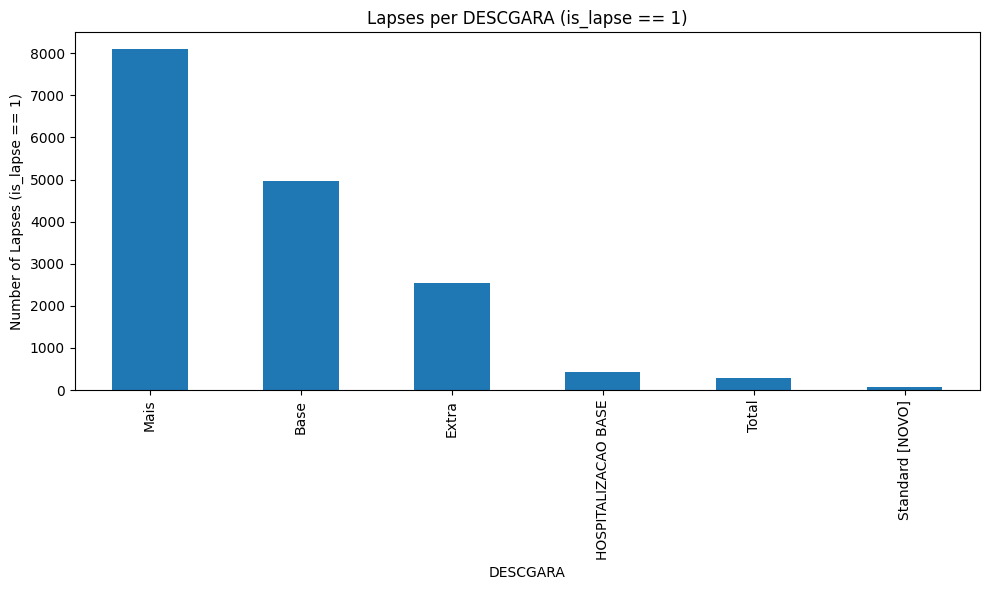

In [ ]:
# Count lapses (has_lapse == 1) per DESCGARA in lapses_pp
descgara_lapse_counts = lapses_pp[lapses_pp['is_lapse'] == 1]['DESCGARA'].value_counts().sort_values(ascending=False)

# Create bar plot
plt.figure(figsize=(10,6))
descgara_lapse_counts.plot(kind='bar')
plt.xlabel('DESCGARA')
plt.ylabel('Number of Lapses (is_lapse == 1)')
plt.title('Lapses per DESCGARA (is_lapse == 1)')
plt.tight_layout()
plt.show()

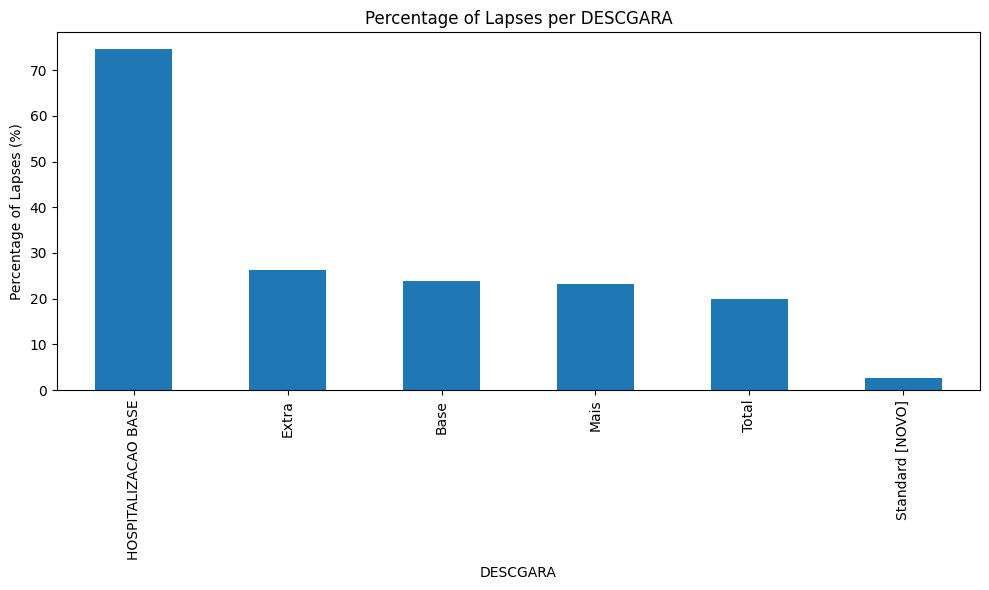

In [ ]:
# Calculate percentage of lapses per DESCGARA
# Total number of POLIZAS per DESCGARA
total_per_descgara = lapses_pp['DESCGARA'].value_counts().sort_index()
# Number of lapses (has_lapse == 1) per DESCGARA
lapses_per_descgara = lapses_pp[lapses_pp['is_lapse'] == 1]['DESCGARA'].value_counts().sort_index()
# Calculate percentage
percentage_lapses = (lapses_per_descgara / total_per_descgara * 100).fillna(0).sort_values(ascending=False)

# Create bar plot
plt.figure(figsize=(10,6))
percentage_lapses.plot(kind='bar')
plt.xlabel('DESCGARA')
plt.ylabel('Percentage of Lapses (%)')
plt.title('Percentage of Lapses per DESCGARA')
plt.tight_layout()
plt.show()

In [ ]:


# Count the number of POLIZAS per DESCGARA type
polizas_per_descgara = lapses_pp['DESCGARA'].value_counts()
print(polizas_per_descgara)

DESCGARA
Mais                   34817
Base                   20879
Extra                   9661
Standard [NOVO]         2504
Total                   1455
HOSPITALIZACAO BASE      566
Name: count, dtype: int64


In [ ]:
# Count the number of rows where has_lapse == 1 per DESCGARA type
lapses_per_descgara = lapses_pp[lapses_pp['is_lapse'] == 1]['DESCGARA'].value_counts()
print(lapses_per_descgara)

DESCGARA
Mais                   8090
Base                   4962
Extra                  2532
HOSPITALIZACAO BASE     422
Total                   289
Standard [NOVO]          69
Name: count, dtype: int64


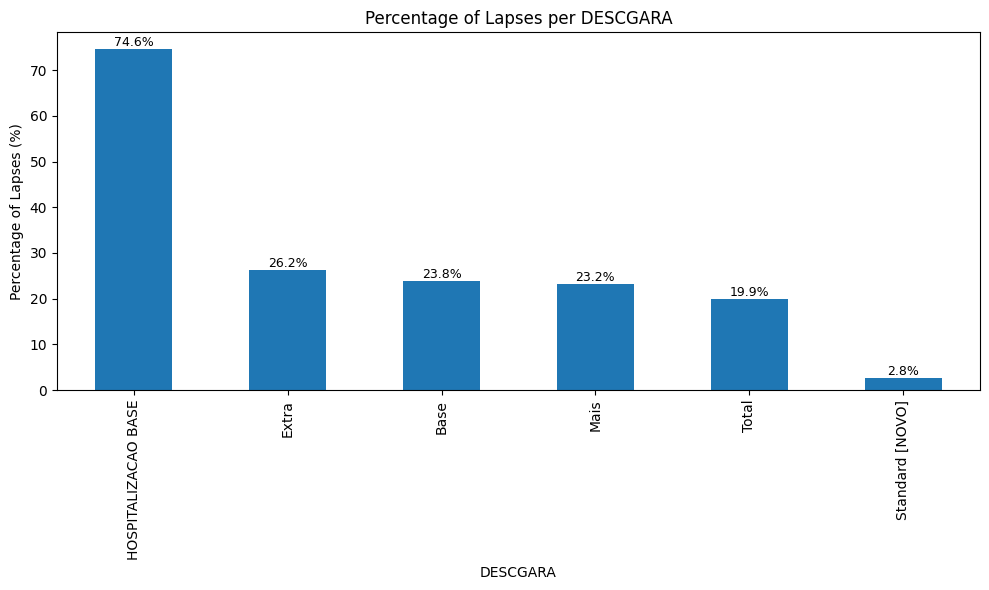

In [ ]:
# Calculate percentage of lapses per DESCGARA
# Total number of POLIZAS per DESCGARA
total_per_descgara = lapses_pp['DESCGARA'].value_counts().sort_index()
# Number of lapses (has_lapse == 1) per DESCGARA
lapses_per_descgara = lapses_pp[lapses_pp['is_lapse'] == 1]['DESCGARA'].value_counts().sort_index()
# Calculate percentage
percentage_lapses = (lapses_per_descgara / total_per_descgara * 100).fillna(0).sort_values(ascending=False)

# Create bar plot with percentage labels
plt.figure(figsize=(10,6))
ax = percentage_lapses.plot(kind='bar')
plt.xlabel('DESCGARA')
plt.ylabel('Percentage of Lapses (%)')
plt.title('Percentage of Lapses per DESCGARA')
plt.tight_layout()

# Add percentage labels on bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color='black', rotation=0)

plt.show()


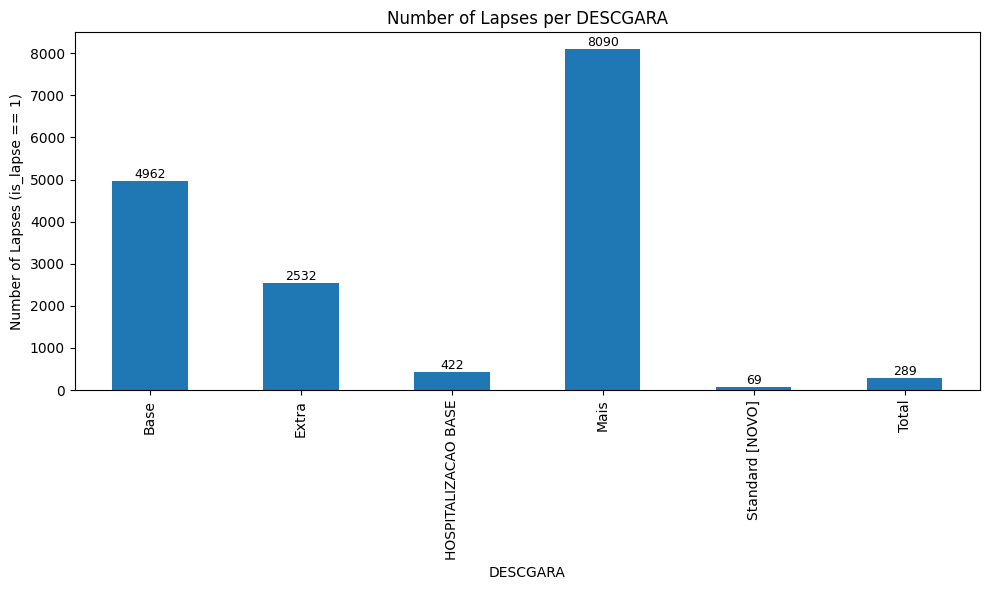

In [ ]:
# Plot the number of lapses (has_lapse == 1) per DESCGARA type
plt.figure(figsize=(10,6))
ax = lapses_per_descgara.plot(kind='bar')
plt.xlabel('DESCGARA')
plt.ylabel('Number of Lapses (is_lapse == 1)')
plt.title('Number of Lapses per DESCGARA')
plt.tight_layout()

# Add value labels on bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color='black', rotation=0)

plt.show()


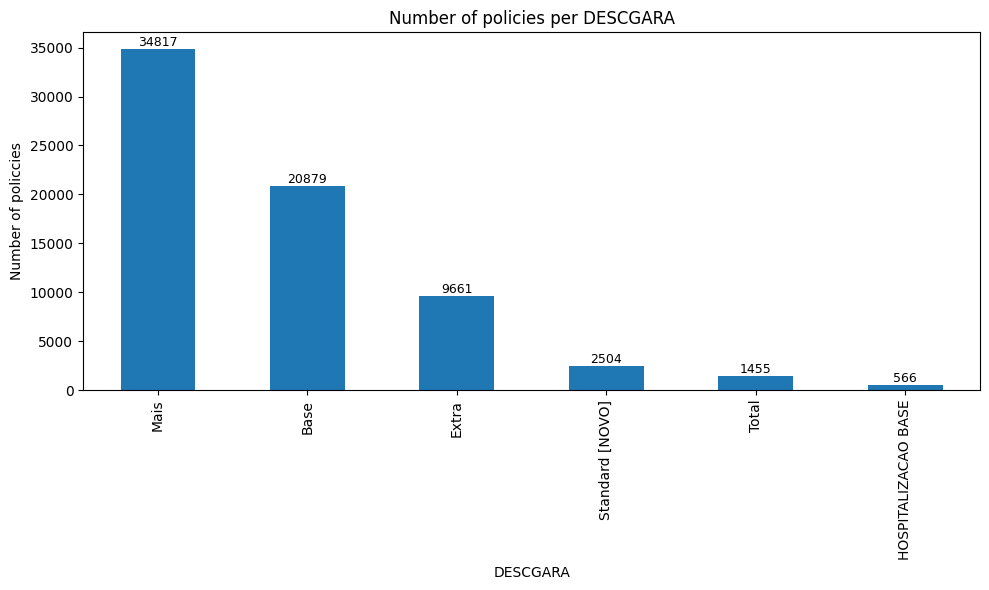

In [ ]:
# Plot the number of lapses (has_lapse == 1) per DESCGARA type
plt.figure(figsize=(10,6))
ax = polizas_per_descgara.plot(kind='bar')
plt.xlabel('DESCGARA')
plt.ylabel('Number of policcies')
plt.title('Number of policies per DESCGARA')
plt.tight_layout()

# Add value labels on bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color='black', rotation=0)

plt.show()


# plot the number of policies per type of policy 

C:\Users\E982233\AppData\Local\Temp\ipykernel_20484\2493665928.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(polizas_per_descgara.index, rotation=45, ha='right')


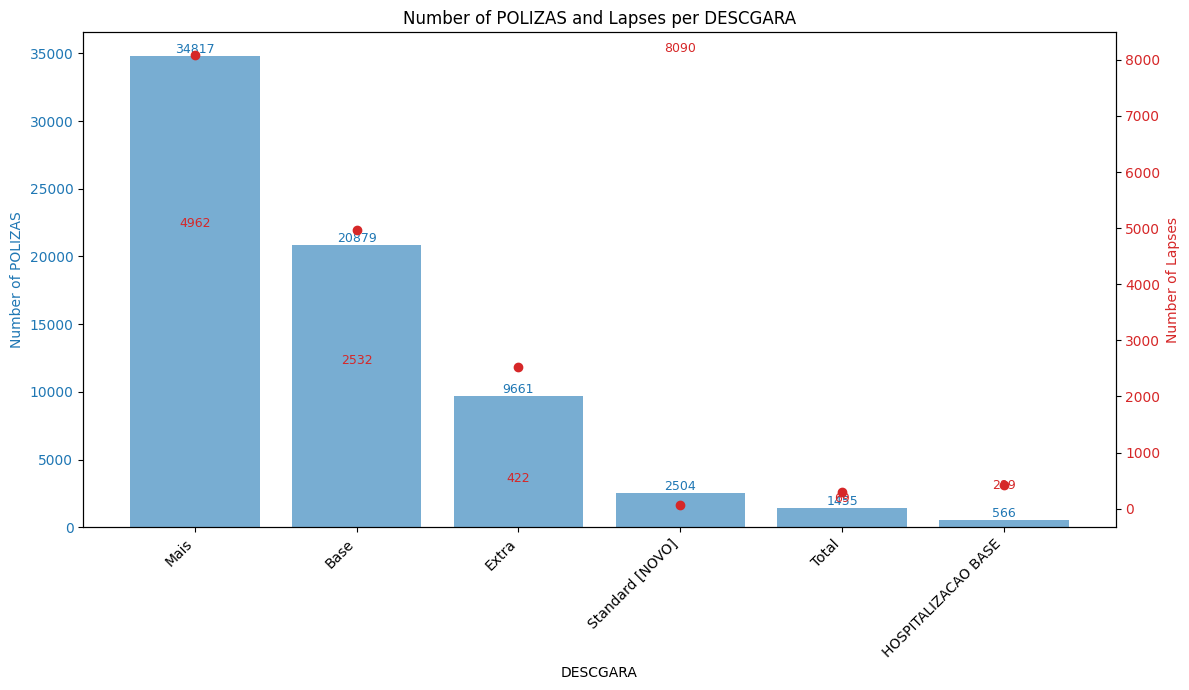

In [ ]:
# Plot number of POLIZAS and number of lapses per DESCGARA on the same graph with dual y-axes
fig, ax1 = plt.subplots(figsize=(12,7))

# Bar plot for number of POLIZAS per DESCGARA (left y-axis)
color1 = 'tab:blue'
polizas_bars = ax1.bar(polizas_per_descgara.index, polizas_per_descgara.values, color=color1, alpha=0.6, label='Number of POLIZAS')
ax1.set_xlabel('DESCGARA')
ax1.set_ylabel('Number of POLIZAS', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticklabels(polizas_per_descgara.index, rotation=45, ha='right')

# Add value labels for POLIZAS
for p in polizas_bars:
    height = p.get_height()
    if not np.isnan(height):
        ax1.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color=color1, rotation=0)

# Create a second y-axis for number of lapses
ax2 = ax1.twinx()
color2 = 'tab:red'
lapses_bars = ax2.scatter(lapses_per_descgara.index, lapses_per_descgara.values, color=color2, label='Number of Lapses', zorder=5)
ax2.set_ylabel('Number of Lapses', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Add value labels for Lapses
for i, v in enumerate(lapses_per_descgara.values):
    if not np.isnan(v):
        ax2.annotate(f'{int(v)}', (i, v), ha='center', va='bottom', fontsize=9, color=color2)

plt.title('Number of POLIZAS and Lapses per DESCGARA')
fig.tight_layout()
plt.show()

## by premio

In [ ]:
# Plot regression of lapses (has_lapse == 1) per premio2 in lapses_pp


# Filter to rows with non-null premio2
lapses_pp_valid = lapses_pp.dropna(subset=['premio2'])

plt.figure(figsize=(10,6))
# Scatter plot with regression line
sns.regplot(x='premio2', y='has_lapse', data=lapses_pp_valid, logistic=True, ci=95, scatter_kws={'alpha':0.3})
plt.xlabel('Premio2')
plt.ylabel('Probability of Lapse (has_lapse == 1)')
plt.title('Logistic Regression: Probability of Lapse vs Premio2')
plt.tight_layout()
plt.show()

KeyError: ['premio2']

In [ ]:
# Bar plot: Number of lapses per premio2 bin (bin size 100, starting at 100, max 1300)

# Filter to rows with non-null premio2 and premio2 <= 1300
lapses_pp_valid = lapses_pp.dropna(subset=['premio2'])
lapses_pp_valid = lapses_pp_valid[lapses_pp_valid['premio2'] <= 1300]

# Define bins
bin_width = 100
min_bin = 100
max_bin = 1300
bins = np.arange(min_bin, max_bin + bin_width, bin_width)

# Bin premio2
lapses_pp_valid['premio2_bin'] = pd.cut(lapses_pp_valid['premio2'], bins=bins, right=False)

# Count number of lapses per bin
lapses_per_bin = lapses_pp_valid[lapses_pp_valid['has_lapse'] == 1]['premio2_bin'].value_counts().sort_index()

plt.figure(figsize=(12,6))
ax = lapses_per_bin.plot(kind='bar', color='tab:red', alpha=0.7)
plt.xlabel('Premio2 Bin (intervals of 100, up to 1300)')
plt.ylabel('Number of Lapses (has_lapse == 1)')
plt.title('Number of Lapses per Premio2 Bin (<=1300)')
plt.tight_layout()

# Add value labels on bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color='black', rotation=0)

plt.show()

In [ ]:
# Bar plot: Percentage of lapses per premio2 bin (bin size 100, starting at 100, max 1300)

# Use the same filtered DataFrame and bins as before
# Count total policies per bin
polizas_per_bin = lapses_pp_valid['premio2_bin'].value_counts().sort_index()

# Calculate percentage of lapses per bin
percentage_lapses_per_bin = (lapses_per_bin / polizas_per_bin * 100).fillna(0)

plt.figure(figsize=(12,6))
ax = percentage_lapses_per_bin.plot(kind='bar', color='tab:blue', alpha=0.7)
plt.xlabel('Premio2 Bin (intervals of 100, up to 1300)')
plt.ylabel('Percentage of Lapses (%)')
plt.title('Percentage of Lapses per Premio2 Bin (<=1300)')
plt.tight_layout()

# Add value labels on bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color='black', rotation=0)

plt.show()

In [ ]:
# Bar plot: Number of lapses per tenure bin (bin size 1, starting at 0, max 20)

# Filter to rows with non-null tenure and tenure <= 20
lapses_pp_valid_tenure = lapses_pp.dropna(subset=['tenure'])
lapses_pp_valid_tenure = lapses_pp_valid_tenure[lapses_pp_valid_tenure['tenure'] <= 8]

# Define bins for tenure
bin_width_tenure = 1
min_bin_tenure = 0
max_bin_tenure = 8
bins_tenure = np.arange(min_bin_tenure, max_bin_tenure + bin_width_tenure, bin_width_tenure)

# Bin tenure
lapses_pp_valid_tenure['tenure_bin'] = pd.cut(lapses_pp_valid_tenure['tenure'], bins=bins_tenure, right=False)

# Count number of lapses per tenure bin
lapses_per_tenure_bin = lapses_pp_valid_tenure[lapses_pp_valid_tenure['has_lapse'] == 1]['tenure_bin'].value_counts().sort_index()

plt.figure(figsize=(12,6))
ax = lapses_per_tenure_bin.plot(kind='bar', color='tab:blue', alpha=0.7)
plt.xlabel('Tenure Bin (years)')
plt.ylabel('Number of Lapses (has_lapse == 1)')
plt.title('Number of Lapses per Tenure Bin (<=20 years)')
plt.tight_layout()

# Add value labels on bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color='black', rotation=0)

plt.show()

In [ ]:
# Bar plot: Percentage of lapses per tenure bin (bin size 1, starting at 0, max 8)

# Count total policies per tenure bin
polizas_per_tenure_bin = lapses_pp_valid_tenure['tenure_bin'].value_counts().sort_index()

# Calculate percentage of lapses per tenure bin
percentage_lapses_per_tenure_bin = (lapses_per_tenure_bin / polizas_per_tenure_bin * 100).fillna(0)

plt.figure(figsize=(12,6))
ax = percentage_lapses_per_tenure_bin.plot(kind='bar', color='tab:orange', alpha=0.7)
plt.xlabel('Tenure Bin (years)')
plt.ylabel('Percentage of Lapses (%)')
plt.title('Percentage of Lapses per Tenure Bin (<=8 years)')
plt.tight_layout()

# Add value labels on bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color='black', rotation=0)

plt.show()

In [ ]:
plot_lapses_by_col(lapses_pp, 'DESCGARA')

### per number of persons in policy


In [ ]:
POLIZA_p_np = lapses_pp.groupby('POLIZA')['n_pessoas_ren2'].sum()
print(POLIZA_p_np)



In [ ]:
# Plot lapses per n_pessoas_ren2 (number and percentage) for values 1 to 6


# Filter valid values
valid = lapses_pp.dropna(subset=['n_pessoas_ren2'])
valid = valid[valid['n_pessoas_ren2'].isin([1,2,3,4,5,6])]

# Number of lapses per value
lapses_per_value = valid[valid['has_lapse'] == 1]['n_pessoas_ren2'].value_counts().sort_index()
# Total per value
total_per_value = valid['n_pessoas_ren2'].value_counts().sort_index()
# Percentage per value
percentage_lapses = (lapses_per_value / total_per_value * 100).fillna(0)

# Plot number of lapses
plt.figure(figsize=(8,4))
ax1 = lapses_per_value.plot(kind='bar', color='tab:red', alpha=0.7)
plt.xlabel('n_pessoas_ren2')
plt.ylabel('Number of Lapses (has_lapse == 1)')
plt.title('Number of Lapses per n_pessoas_ren2')
plt.tight_layout()
for p in ax1.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax1.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color='black', rotation=0)
plt.show()

# Plot percentage of lapses
plt.figure(figsize=(8,4))
ax2 = percentage_lapses.plot(kind='bar', color='tab:blue', alpha=0.7)
plt.xlabel('n_pessoas_ren2')
plt.ylabel('Percentage of Lapses (%)')
plt.title('Percentage of Lapses per n_pessoas_ren2')
plt.tight_layout()
for p in ax2.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax2.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color='black', rotation=0)
plt.show()

In [ ]:
plot_lapses_by_col(lapses_pp, 'Tp_cliente')

### per new bussines and old bussiness


In [ ]:

# Convert POLIZASNP column to categorical: 0 if False, 1 if True
if 'POLIZASNP' in lapses_pp.columns:
    lapses_pp['POLIZASNP'] = lapses_pp['POLIZASNP'].astype(bool).astype(int)
else:
    print('Column POLIZASNP does not exist in lapses_pp.')

In [ ]:

plot_lapses_by_col(lapses_pp, 'POLIZASNP')

In [ ]:
# Plot the number of lapses per POLIZASNP (categorical)
lapses_per_polizasnp = lapses_pp[lapses_pp['has_lapse'] == 1]['POLIZASNP'].value_counts().sort_index()


plt.figure(figsize=(6,4))
ax = lapses_per_polizasnp.plot(kind='bar', color='tab:purple', alpha=0.7)
plt.xlabel('POLIZASNP (0 = False, 1 = True)')
plt.ylabel('Number of Lapses (has_lapse == 1)')
plt.title('Number of Lapses per POLIZASNP')
plt.tight_layout()
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=9, color='black', rotation=0)
plt.show()

In [ ]:
# Count rows where PRIANUALAC is different from premio2
if 'PRIANUALAC' in lapses_pp.columns and 'premio2' in lapses_pp.columns:
    diff_rows = lapses_pp[lapses_pp['PRIANUALAC'] != lapses_pp['premio2']]
    print(f"Number of rows where PRIANUALAC is different from premio2: {len(diff_rows)}")
    # Optionally, show the rows
    # print(diff_rows)
else:
    print('Column PRIANUALAC or premio2 does not exist in lapses_pp.')

In [ ]:
# Violin plot: relation of premio2 and has_lapse
import seaborn as sns
import matplotlib.pyplot as plt

# Filter valid values
valid = lapses_pp.dropna(subset=['premio2', 'has_lapse'])

plt.figure(figsize=(10,6))
sns.violinplot(x='has_lapse', y='premio2', data=valid, palette='Set2')
plt.xlabel('Has Lapse (0 = No, 1 = Yes)')
plt.ylabel('Premio2')
plt.title('Violin Plot of Premio2 by Has Lapse')
plt.tight_layout()
plt.show()

In [ ]:
plot_lapses_by_col(lapses_pp, 'SEXO_tom')

In [ ]:
plot_lapses_by_col(lapses_pp, 'IDADE_tom')

In [ ]:
plot_lapses_by_col(lapses_pp, 'n_filhos')

In [ ]:
plot_lapses_by_col(lapses_pp, 'score_final')

In [ ]:
plot_lapses_by_col(lapses_pp, 'Distrito')

In [ ]:
plot_lapses_by_col(lapses_pp, 'purch_power_Euro')

In [ ]:
plot_lapses_by_col(lapses_pp, 'TOT_SINIST')

In [ ]:
plot_lapses_by_col(lapses_pp, 'N_MED_PG_SN')

In [ ]:
plot_lapses_by_col(lapses_pp, 'FCob') 

## dealing with nan

In [ ]:
lapses_pp.isna()

In [ ]:
# Analyze NaN values in lapses_pp
nan_summary = lapses_pp.isnull().sum().sort_values(ascending=False)
print('Number of NaN values per column:')
print(nan_summary)

# Percentage of NaN values per column
nan_percentage = (lapses_pp.isnull().mean() * 100).sort_values(ascending=False)
print('\nPercentage of NaN values per column:')
print(nan_percentage)

# Show rows with any NaN values (optional, can be large)
# print(lapses_pp[lapses_pp.isnull().any(axis=1)])

Number of NaN values per column:
fbajaaseg                                 42259
premio2021                                24221
premio2022                                24221
premio2024                                22043
premio2025                                21636
premio2023                                21290
score_final                               14645
IMC_tom                                    6284
POP_idade08_45_49anos                      2950
POP_idade09_50_54anos                      2950
POP_index_trafg_dens_temp_motjov           2950
POP_idade01_0_14anos                       2950
POP_idade02_15_19anos                      2950
POP_idade03_20_24anos                      2950
POP_idade04_25_29anos                      2950
POP_idade05_30_34anos                      2950
POP_indice_dependencia_idosos              2950
POP_indice_envelhecimento                  2950
POP_ES_completo                            2950
POP_residente_idade_media                  2950
POP_tax

In [ ]:
lapses_pp['ESTATURA_med_fil'] = lapses_pp['ESTATURA_med_fil'].fillna(0)

In [ ]:
lapses_pp['N_MED_PG_SN'] = lapses_pp['N_MED_PG_SN'].fillna(0)

In [ ]:
lapses_pp.shape

(69551, 238)

In [ ]:
# Show entries where POP_ES_completo is missing, displaying only Concelho and Distrito columns
missing_pop_es = lapses_pp[lapses_pp['POP_ES_completo'].isnull()][['Concelho', 'Distrito']]
print(missing_pop_es)

                       Concelho             Distrito
50                      AMADORA               LISBOA
63                        LAGOA                 FARO
111             FIGUEIRA DA FOZ              COIMBRA
126                       LAGOA                 FARO
184               TORRES VEDRAS               LISBOA
192                    SANTAREM             SANTAREM
278               TORRES VEDRAS               LISBOA
314                       VISEU                VISEU
320           MOIMENTA DA BEIRA                VISEU
329                       LAGOA                 FARO
361                       LAGOS                 FARO
383                       VISEU                VISEU
400                     AMADORA               LISBOA
401                     AMADORA               LISBOA
414          MARCO DE CANAVESES                PORTO
420                     AMADORA               LISBOA
480                       VISEU                VISEU
485                    SANTAREM             SA

In [ ]:
lapses_pp.columns.get_loc("N_hospitais_PP")

53

In [ ]:

lapses_pp.columns.get_loc("N_hospitais_PP")

53

In [ ]:
lapses_pp.shape

(69551, 238)

In [ ]:
# Count the number of lapses (has_lapse == 1) and compute the percentage
num_lapses = lapses_pp[lapses_pp['is_lapse'] == 1].shape[0]
total_rows = lapses_pp.shape[0]
lapse_percentage = (num_lapses / total_rows) * 100 if total_rows > 0 else 0
print(f"Number of lapses: {num_lapses}")
print(f"Percentage of lapses: {lapse_percentage:.2f}%")

Number of lapses: 16364
Percentage of lapses: 23.42%


In [ ]:
# Identify columns with 2 or more data types
mixed_type_cols = {}
for col in lapses_pp.columns:
    types_in_col = set(type(x) for x in lapses_pp[col].dropna())
    if len(types_in_col) > 1:
        mixed_type_cols[col] = types_in_col
print("Columns with mixed data types:")
for col, types_found in mixed_type_cols.items():
    print(f"{col}: {types_found}")

Columns with mixed data types:
SEXO_conj: {<class 'int'>, <class 'str'>}
N_pessoas_total: {<class 'int'>, <class 'str'>, <class 'float'>}
N_Homens: {<class 'int'>, <class 'str'>, <class 'float'>}
N_Mulheres: {<class 'int'>, <class 'str'>, <class 'float'>}
N_hospitais_total: {<class 'int'>, <class 'str'>, <class 'float'>}
N_hospitais_Publico: {<class 'int'>, <class 'str'>, <class 'float'>}
N_hospitais_Privado: {<class 'int'>, <class 'str'>, <class 'float'>}
N_hospitais_PP: {<class 'int'>, <class 'str'>, <class 'float'>}
new_nif_tomador: {<class 'int'>, <class 'str'>, <class 'float'>}


In [ ]:
# Count the number of rows where new_nif_tomador is 'EXTR9'
extr9_count = lapses_pp[lapses_pp['new_nif_tomador'] == 'EXTR99'].shape[0]
print(f"Number of rows where new_nif_tomador == 'EXTR99': {extr9_count}")

Number of rows where new_nif_tomador == 'EXTR99': 13


In [ ]:
lapses_pp

KeyboardInterrupt: 

In [ ]:
lapses_pp.columns.get_loc("Avg_Number_Floors")

36

In [ ]:
lapses_pp.columns.get_loc("N_hospitais_PP")

53

In [ ]:
lapses_pp.columns[36:54]

Index(['Avg_Number_Floors', 'Crime_rate_Avg', 'households', 'inhabitants',
       'purch_power_Euro', 'Distrito', 'Concelho', 'N_Clientes',
       'N_Prestadores', 'N_Domicilios', 'Concentracao', 'N_pessoas_total',
       'N_Homens', 'N_Mulheres', 'N_hospitais_total', 'N_hospitais_Publico',
       'N_hospitais_Privado', 'N_hospitais_PP'],
      dtype='object')

In [ ]:
cols_to_fill = lapses_pp.columns[34:54]
for col in cols_to_fill:
    # First, fill NaN using exact codpost_tom match
    lapses_pp[col] = lapses_pp.groupby('codpost_tom')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
    # For remaining NaNs, try matching on first 4 digits of codpost_tom
    mask = lapses_pp[col].isna()
    if mask.any():
        # Create a helper column for first 4 digits
        lapses_pp['codpost_prefix'] = lapses_pp['codpost_tom'].astype(str).str[:4]
        fill_map = lapses_pp.groupby('codpost_prefix')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
        lapses_pp.loc[mask, col] = fill_map[mask]
# Remove helper column
lapses_pp.drop(columns='codpost_prefix', inplace=True)

C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\2304234035.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lapses_pp[col] = lapses_pp.groupby('codpost_tom')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\2304234035.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lapses_pp[col] = lapses_pp.groupby('codpost_tom')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\2304234035.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lapses_pp[col] = lapses_pp.groupby('codpost_tom')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
C:\Users\E982233

In [ ]:
# Show the number of NaNs for columns with indexes 34 to 54
cols_to_check = lapses_pp.columns[34:54]
nan_counts = lapses_pp[cols_to_check].isnull().sum()
print('Number of NaN values per column (indexes 34 to 51):')
print(nan_counts)

Number of NaN values per column (indexes 34 to 51):
tenure                  0
new_ant_pessoa          0
Avg_Number_Floors      23
Crime_rate_Avg         23
households             23
inhabitants            23
purch_power_Euro       23
Distrito               23
Concelho               23
N_Clientes             23
N_Prestadores          23
N_Domicilios           23
Concentracao           23
N_pessoas_total        23
N_Homens               23
N_Mulheres             23
N_hospitais_total      23
N_hospitais_Publico    23
N_hospitais_Privado    23
N_hospitais_PP         23
dtype: int64


In [ ]:
# Further fill NaNs in cols 34 to 51 using first 2 and then first 1 character(s) of codpost_tom
cols_to_fill = lapses_pp.columns[34:54]
for col in cols_to_fill:
    # Fill using first 2 digits of codpost_tom
    mask = lapses_pp[col].isna()
    if mask.any():
        lapses_pp['codpost_prefix2'] = lapses_pp['codpost_tom'].astype(str).str[:2]
        fill_map2 = lapses_pp.groupby('codpost_prefix2')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
        lapses_pp.loc[mask, col] = fill_map2[mask]
    # Fill using first 1 digit of codpost_tom
    mask = lapses_pp[col].isna()
    if mask.any():
        lapses_pp['codpost_prefix1'] = lapses_pp['codpost_tom'].astype(str).str[:1]
        fill_map1 = lapses_pp.groupby('codpost_prefix1')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
        lapses_pp.loc[mask, col] = fill_map1[mask]
# Remove helper columns
lapses_pp.drop(columns=['codpost_prefix2', 'codpost_prefix1'], inplace=True)

C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\523141458.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['codpost_prefix2'] = lapses_pp['codpost_tom'].astype(str).str[:2]
C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\523141458.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fill_map2 = lapses_pp.groupby('codpost_prefix2')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\523141458.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at onc

In [ ]:
# Count rows where Avg_Number_Floors is NaN
nan_rows = lapses_pp['Avg_Number_Floors'].isna()
total_nan = nan_rows.sum()
lapse_nan = lapses_pp[nan_rows & (lapses_pp['is_lapse'] == 1)].shape[0]
print(f"Rows where Avg_Number_Floors is NaN: {total_nan}")
print(f"Of those, rows with has_lapse == 1: {lapse_nan}")

Rows where Avg_Number_Floors is NaN: 23
Of those, rows with has_lapse == 1: 4


In [ ]:
# Show rows where Avg_Number_Floors is NaN and has_lapse == 1
nan_lapse_rows = lapses_pp[lapses_pp['Avg_Number_Floors'].isna() & (lapses_pp['is_lapse'] == 1)]
print(nan_lapse_rows)

          POLIZA  is_lapse  midterm fefecto_poliza codpost_tom     Tp_cliente  \
9425   205591932         1        0     2020-02-01           -  01_Individual   
11514  205660880         1        0     2020-03-01       0-000  01_Individual   
15555  205718000         1        0     2020-05-01       0000-  01_Individual   
25419  205865350         1        0     2020-10-01       0-000  01_Individual   

       POLIZASNP  ICART_MES  ICART_DIA  fbajaaseg  ... Social_susceptibility  \
9425         0.0          2          1 2022-02-01  ...                   NaN   
11514        0.0          3          1 2024-03-01  ...                   NaN   
15555        0.0          5          1 2022-05-01  ...                   NaN   
25419        0.0         10          1 2022-10-01  ...                   NaN   

                  DESCGARA  n_pessoas_ren2  CHANGE_in_people  premio2  \
9425   HOSPITALIZACAO BASE             2.0               0.0   144.34   
11514                Extra             4.0     

In [ ]:
lapses_pp


In [ ]:
lapses_pp.columns.get_loc("POP_indice_envelhecimento")

80

In [ ]:
lapses_pp.columns.get_loc("POP_GSE24_emprs_SP")

179

In [ ]:
# Fill NaNs in columns 78 to 177 using values from other rows with the same codpost_tom
cols_to_fill = lapses_pp.columns[80:180]
for col in cols_to_fill:
    lapses_pp[col] = lapses_pp.groupby('codpost_tom')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))

C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\4174076157.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lapses_pp[col] = lapses_pp.groupby('codpost_tom')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\4174076157.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lapses_pp[col] = lapses_pp.groupby('codpost_tom')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\4174076157.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lapses_pp[col] = lapses_pp.groupby('codpost_tom')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
C:\Users\E982233

In [ ]:
lapses_pp.columns[80:181]

Index(['POP_indice_envelhecimento', 'POP_indice_dependencia_idosos',
       'POP_durac_media_mov_pendular', 'POP_taxa_desemprego',
       'POP_ES_completo', 'POP_residente_idade_media', 'POP_ADP_dim_media',
       'POP_AI_dim_media', 'POP_NclF_monoparentais', 'POP_NclF_com_filhos',
       ...
       'POP_GSE16_trab_industr_AI', 'POP_GSE17_prof_tecn_interm_I',
       'POP_GSE18_prof_intelc_cientf', 'POP_GSE19_pequenos_patroes_SP',
       'POP_GSE20_pequenos_patroes_CS', 'POP_GSE21_pequenos_patroes_I',
       'POP_GSE22_pequenos_patroes_PTI', 'POP_GSE23_pequenos_patroes_PIC',
       'POP_GSE24_emprs_SP', 'POP_GSE25_outras_pess_atv_NE'],
      dtype='object', length=101)

In [ ]:
lapses_pp

In [ ]:
# Fill NaNs in columns 78 to 177 using first 4, then 2, then 1 digit(s) of codpost_tom
cols_to_fill = lapses_pp.columns[80:182]
for col in cols_to_fill:
    # Fill using first 4 digits
    mask = lapses_pp[col].isna()
    if mask.any():
        lapses_pp['codpost_prefix4'] = lapses_pp['codpost_tom'].astype(str).str[:4]
        fill_map4 = lapses_pp.groupby('codpost_prefix4')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
        lapses_pp.loc[mask, col] = fill_map4[mask]
    # Fill using first 2 digits
    mask = lapses_pp[col].isna()
    if mask.any():
        lapses_pp['codpost_prefix2'] = lapses_pp['codpost_tom'].astype(str).str[:2]
        fill_map2 = lapses_pp.groupby('codpost_prefix2')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
        lapses_pp.loc[mask, col] = fill_map2[mask]
    # Fill using first 1 digit
    mask = lapses_pp[col].isna()
    if mask.any():
        lapses_pp['codpost_prefix1'] = lapses_pp['codpost_tom'].astype(str).str[:1]
        fill_map1 = lapses_pp.groupby('codpost_prefix1')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
        lapses_pp.loc[mask, col] = fill_map1[mask]
# Remove helper columns
lapses_pp.drop(columns=['codpost_prefix4', 'codpost_prefix2', 'codpost_prefix1'], inplace=True)

C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\2399759356.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  lapses_pp['codpost_prefix4'] = lapses_pp['codpost_tom'].astype(str).str[:4]
C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\2399759356.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fill_map4 = lapses_pp.groupby('codpost_prefix4')[col].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\2399759356.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at 

In [ ]:
# Get the names of columns that have NaN values
nan_cols = lapses_pp.columns[lapses_pp.isnull().any()].tolist()
print('Columns with NaN values:')
print(nan_cols)

Columns with NaN values:
['fbajaaseg', 'SEXO_tom', 'new_estatura_tom', 'PESO_tom', 'IDADE_tom', 'IMC_tom', 'ICORR', 'prem_inicial', 'Avg_Number_Floors', 'Crime_rate_Avg', 'households', 'inhabitants', 'purch_power_Euro', 'Distrito', 'Concelho', 'N_Clientes', 'N_Prestadores', 'N_Domicilios', 'Concentracao', 'N_pessoas_total', 'N_Homens', 'N_Mulheres', 'N_hospitais_total', 'N_hospitais_Publico', 'N_hospitais_Privado', 'N_hospitais_PP', 'POP_indice_envelhecimento', 'POP_indice_dependencia_idosos', 'POP_durac_media_mov_pendular', 'POP_taxa_desemprego', 'POP_ES_completo', 'POP_residente_idade_media', 'POP_ADP_dim_media', 'POP_AI_dim_media', 'POP_NclF_monoparentais', 'POP_NclF_com_filhos', 'POP_meio_transp_total_abs', 'POP_PMT_index_trafego_auto', 'POP_meio_transp_index_saudavel', 'POP_index_trafg_dens_auto', 'POP_index_trafg_dens_temp_auto', 'POP_index_trafg_dens_saudavel', 'POP_ix_trafg_dens_temp_saudavel', 'POP_index_trafg_dens_motjov', 'POP_index_trafg_dens_temp_motjov', 'POP_idade01_0_14

In [ ]:
# Get the names of columns that have NaN values
nan_cols = lapses_pp.columns[lapses_pp.isnull().any()].tolist()
print('Columns with NaN values:')
print(nan_cols)

Columns with NaN values:
['fbajaaseg', 'IMC_tom', 'score_final', 'new_nif_tomador', 'Precipitation', 'Physical_Susceptibility', 'Social_susceptibility', 'n_pessoas_ren2', 'CHANGE_in_people', 'premio2021', 'premio2022', 'premio2023', 'premio2024', 'premio2025']


In [ ]:
# Get the names of columns that have NaN values
nan_cols = lapses_pp.columns[lapses_pp.isnull().any()].tolist()
print('Columns with NaN values:')
print(nan_cols)

In [ ]:
nan_cols = lapses_pp.columns[lapses_pp.isnull().any()].tolist()
print('Columns with NaN values:')
print(nan_cols)

In [ ]:
# Fill NaNs in specific columns using codpost_tom matching: full, then 4, 3, 2, 1 digits
cols_to_fill = ['Precipitation', 'Physical_Susceptibility', 'Social_susceptibility']
for col_to_fill in cols_to_fill:
    mask = lapses_pp[col_to_fill].isna()
    # Try full codpost_tom match
    if mask.any():
        fill_map_full = lapses_pp.groupby('codpost_tom')[col_to_fill].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
        lapses_pp.loc[mask, col_to_fill] = fill_map_full[mask]
    # Try first 4 digits
    mask = lapses_pp[col_to_fill].isna()
    if mask.any():
        lapses_pp['codpost_prefix4'] = lapses_pp['codpost_tom'].astype(str).str[:4]
        fill_map4 = lapses_pp.groupby('codpost_prefix4')[col_to_fill].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
        lapses_pp.loc[mask, col_to_fill] = fill_map4[mask]
    # Try first 3 digits
    mask = lapses_pp[col_to_fill].isna()
    if mask.any():
        lapses_pp['codpost_prefix3'] = lapses_pp['codpost_tom'].astype(str).str[:3]
        fill_map3 = lapses_pp.groupby('codpost_prefix3')[col_to_fill].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
        lapses_pp.loc[mask, col_to_fill] = fill_map3[mask]
    # Try first 2 digits
    mask = lapses_pp[col_to_fill].isna()
    if mask.any():
        lapses_pp['codpost_prefix2'] = lapses_pp['codpost_tom'].astype(str).str[:2]
        fill_map2 = lapses_pp.groupby('codpost_prefix2')[col_to_fill].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
        lapses_pp.loc[mask, col_to_fill] = fill_map2[mask]
    # Try first 1 digit
    mask = lapses_pp[col_to_fill].isna()
    if mask.any():
        lapses_pp['codpost_prefix1'] = lapses_pp['codpost_tom'].astype(str).str[:1]
        fill_map1 = lapses_pp.groupby('codpost_prefix1')[col_to_fill].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))
        lapses_pp.loc[mask, col_to_fill] = fill_map1[mask]
# Remove helper columns
lapses_pp.drop(columns=['codpost_prefix4', 'codpost_prefix3', 'codpost_prefix2', 'codpost_prefix1'], inplace=True)

In [ ]:
lapses_pp

In [ ]:
# Assign 5 to all NaN values in the Precipitation column
lapses_pp['Precipitation'].fillna(5, inplace=True)

C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\3097881424.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lapses_pp['Precipitation'].fillna(5, inplace=True)


In [ ]:
lapses_pp['Physical_Susceptibility'].fillna(5, inplace=True)

C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\2570194197.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lapses_pp['Physical_Susceptibility'].fillna(5, inplace=True)


In [ ]:
lapses_pp["Social_susceptibility"].fillna(2,inplace=True)

C:\Users\E982233\AppData\Local\Temp\ipykernel_20064\2504834441.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  lapses_pp["Social_susceptibility"].fillna(2,inplace=True)


In [ ]:
lapses_pp

In [ ]:
nan_cols = lapses_pp.columns[lapses_pp.isnull().any()].tolist()
print(f"collumns with nan values:{nan_cols}")

collumns with nan values:['fbajaaseg', 'IMC_tom', 'score_final', 'new_nif_tomador', 'n_pessoas_ren2', 'CHANGE_in_people', 'premio2021', 'premio2022', 'premio2023', 'premio2024', 'premio2025']


In [125]:
lapses_pp[lapses_pp["n_pessoas_ren2"].isna()].count()

POLIZA                                    60
is_lapse                                  60
midterm                                   60
fefecto_poliza                            60
codpost_tom                               60
Tp_cliente                                60
POLIZASNP                                 60
ICART_MES                                 60
ICART_DIA                                 60
fbajaaseg                                 35
SEXO_tom                                  60
new_estatura_tom                          59
PESO_tom                                  59
IDADE_tom                                 59
IMC_tom                                   59
SEXO_conj                                 60
new_estatura_conj                         60
PESO_conj                                 60
IDADE_conj                                60
IMC_conj                                  60
tot_male_apo                              60
tot_female_apo                            60
n_filhos  

In [128]:
nan_cols = lapses_pp.columns[lapses_pp.isnull().any()].tolist()
print(f"collumns with nan values:{nan_cols}")

collumns with nan values:['fbajaaseg', 'SEXO_tom', 'new_estatura_tom', 'PESO_tom', 'IDADE_tom', 'IMC_tom', 'ICORR', 'prem_inicial', 'Avg_Number_Floors', 'Crime_rate_Avg', 'households', 'inhabitants', 'purch_power_Euro', 'Distrito', 'Concelho', 'N_Clientes', 'N_Prestadores', 'N_Domicilios', 'Concentracao', 'N_pessoas_total', 'N_Homens', 'N_Mulheres', 'N_hospitais_total', 'N_hospitais_Publico', 'N_hospitais_Privado', 'N_hospitais_PP', 'POP_indice_envelhecimento', 'POP_indice_dependencia_idosos', 'POP_durac_media_mov_pendular', 'POP_taxa_desemprego', 'POP_ES_completo', 'POP_residente_idade_media', 'POP_ADP_dim_media', 'POP_AI_dim_media', 'POP_NclF_monoparentais', 'POP_NclF_com_filhos', 'POP_meio_transp_total_abs', 'POP_PMT_index_trafego_auto', 'POP_meio_transp_index_saudavel', 'POP_index_trafg_dens_auto', 'POP_index_trafg_dens_temp_auto', 'POP_index_trafg_dens_saudavel', 'POP_ix_trafg_dens_temp_saudavel', 'POP_index_trafg_dens_motjov', 'POP_index_trafg_dens_temp_motjov', 'POP_idade01_0_14

In [129]:
lapses


KeyboardInterrupt: 

In [130]:
lapses_pp.to_csv("lapses_pp_1.csv", index=False)

In [131]:
lapses.to_csv("lapses_1.csv",index=False)

### explorinh whats wrong with the score col